# Exoplanetary System Habitability Analysis using GNNs

## Context

**1. Introduction**

The goal of this project is to **predict the habitability of planetary systems by representing them as graphs**. In astronomy, a planet’s environment is not isolated. It depends on its host star and its position within the system. For example, Earth would not be habitable if it were orbiting a much hotter star at the same distance, or if its orbit were highly eccentric (non-circular) due to gravitational interference from other planets. We will use Graph Neural Networks (GNNs) to process these complex spatial relationships.

**2. Dataset**

We are using the NASA Exoplanet Archive (Composite Data). This dataset includes physical parameters of thousands of exoplanets and their host stars.
- **Nodes**: Each planet and the host star will be a node.
- **Edges**: Connections between the star and its planets (representing gravitational and energetic influence).
- **Key Features**: Although the dataset contains nearly 100 different parameters, we will focus on a specific set of Key Features. These variables provide the essential physical information needed to detect our target: habitability.
    - **System Structure**
        - **`hostname` (Star Name)**: This is the ID of the star. It helps us group all planets that orbit the same star. Without this, we cannot build the network (the graph).
        - **`sy_pnum` (Number of Planets)**: It tells us how many planets are in the system. We use this to filter out systems with only one planet, as we need multiple nodes to see relationships.
    - **Planet Data**
        - **`pl_orbsmax` (Distance to Star)**: The most important factor. If a planet is too close, it burns; if it is too far, it freezes.
        - **`pl_rade` (Radius)**: Tells us the size. Is it a small rocky world like Earth or a giant gas ball like Jupiter? Life needs solid ground.
        - **`pl_bmasse` (Mass)**: The "weight" of the planet. High mass means crushing gravity; low mass means the planet cannot hold an atmosphere to breathe.
        - **`pl_insol` (Energy Received)**: The actual heat the planet gets from its star. This is the key to knowing if it is "habitable".
        - **`pl_orbeccen` (Orbit Shape)**: Tells us if the orbit is a perfect circle or a stretched oval. A stretched oval causes violent weather changes.
    - **Star Data**
        - **`st_teff` (Star Temperature)**: Tells us the color of the sun. Blue stars are super hot; red stars are cooler and smaller.
        - **`st_mass` (Star Mass)**: Bigger stars have stronger gravity but live very short lives. Small stars live longer, giving life more time to evolve.
        - **`st_met` (Star Metallurgy)**: This tells us if the star has "heavy materials" (like iron or rock). Stars with high metallurgy are more likely to have rocky planets like Earth.

**Note:** All information and column descriptions were taken from the official [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html).

**3. Objectives**

- **Data Engineering**: Clean and filter the NASA dataset, focusing on multi-planetary systems.

- **Graph Construction**: Transform the tabular data into graph structures using PyTorch Geometric.

- **Labeling**: Define a "Habitability Label" based on the Earth Similarity Index (ESI) logic (combining planet size and energy received).

- **Model Implementation**: Build a Graph Convolutional Network (GCN) with a Global Pooling layer to classify entire systems.

- **Handling Imbalance**: Use advanced ML techniques (like weighted loss functions) to handle the scarcity of habitable planets compared to gas giants.

## Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from collections import defaultdict

/home/haizea_gonzalez/Cuarto/segundoCuatri/ml_avanzado/Machine-Learning-Avanzado/.venv/lib/python3.12/site-packages/torch/__config__.py:9: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._show_config()
/home/haizea_gonzalez/Cuarto/segundoCuatri/ml_avanzado/Machine-Learning-Avanzado/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Analysis

The first step in our pipeline is to load the raw data from the NASA Exoplanet Archive. 

The dataset is provided in a .csv format that includes several lines of metadata (comments starting with #). We use the comment parameter to skip these lines and load only the structured table.

In [2]:
file_path = 'data/astroData.csv'
df_raw = pd.read_csv(file_path, comment='#', low_memory=False)

print(f"Dataset loaded with {df_raw.shape[0]} planets and {df_raw.shape[1]} columns.")
df_raw.head()

Dataset loaded with 6286 planets and 84 columns.


,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007.0,Xinglong Station,0,323.21000,0.06,...,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20,...,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008.0,Okayama Astrophysical Observatory,0,186.76000,0.11,...,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826
3,14 Her b,14 Her,1,2,Radial Velocity,2002.0,W. M. Keck Observatory,0,1766.41000,0.67,...,-0.0073,6.61935,0.023,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351
4,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996.0,Multiple Observatories,0,798.50000,1.00,...,-0.0111,6.21500,0.016,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603


Before selecting our final features, we need to understand the **quality of the data**. In exoplanet science, not all parameters are known for every planet. Some might have a measured radius but missing mass, or vice versa.

Missing data can be a problem for our GNN because each node in the graph needs complete information to perform calculations. Our **goals** in this section are:
- Identify which key columns have the most missing values.
- Decide if we should drop the rows with missing data or impute (estimate) them.

/tmp/ipykernel_2136/3416185707.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_summary.index, y=null_summary['Percentage (%)'], palette='coolwarm')


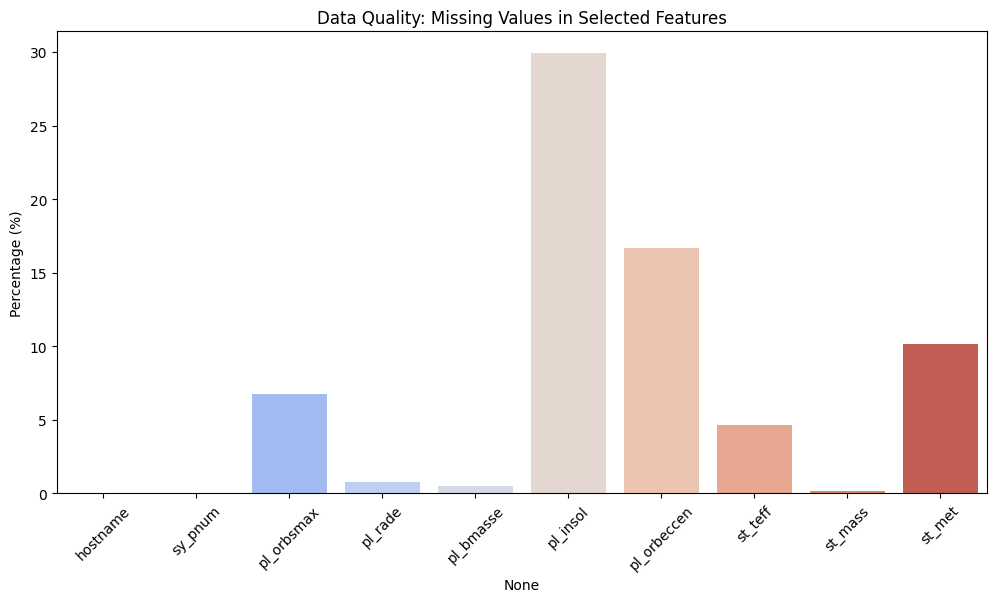

             Null Values  Percentage (%)
pl_insol            1880       29.907731
pl_orbeccen         1049       16.687878
st_met               640       10.181355
pl_orbsmax           426        6.776965
st_teff              294        4.677060
pl_rade               50        0.795418
pl_bmasse             31        0.493159
st_mass                9        0.143175
sy_pnum                0        0.000000
hostname               0        0.000000


In [3]:
# We only want to see the columns we are interested in for our project (explained which ones were selected above)
key_columns = [
    'hostname', 'sy_pnum',          
    'pl_orbsmax', 'pl_rade', 
    'pl_bmasse', 'pl_insol', 
    'pl_orbeccen',                  
    'st_teff', 'st_mass', 'st_met'
]

# Calculate null values and their percentage for the key columns
null_summary = pd.DataFrame({
    'Null Values': df_raw[key_columns].isnull().sum(),
    'Percentage (%)': (df_raw[key_columns].isnull().sum() / len(df_raw)) * 100
})

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=null_summary.index, y=null_summary['Percentage (%)'], palette='coolwarm')
plt.title('Data Quality: Missing Values in Selected Features')
plt.xticks(rotation=45)
plt.ylabel('Percentage (%)')
plt.show()

print(null_summary.sort_values(by='Percentage (%)', ascending=False))

As we discovered, the **Insolation Flux (`pl_insol`) is our most problematic column because it has the highest amount of missing values (nearly 30%)**. Deleting 30% of our planets would be a massive loss of information for our Graph Neural Network.

**The Solution: Physical Imputation**
Instead of discarding this data, we can use a physical model to calculate the missing values. To do this, we need three specific data from our dataset:
1. **Stellar Radius (`st_rad`)**: To know the size of the light source
2. **Stellar Temperature (`st_teff`)**: To know the intensity of the heat.
3. **Distance (`pl_orbsmax`)**: To know how much the energy fades before reaching the planet.

**The Math Behind it**
We use the Stefan-Boltzmann Law and the Inverse Square Law. By comparing the exoplanet's host star to our Sun (which has a reference temperature of 5778K), we can estimate the energy flux using this formula:$$pl\_insol \approx \left( \frac{st\_rad}{pl\_orbsmax} \right)^2 \times \left( \frac{st\_teff}{5778} \right)^4$$

**Execution Strategy**
1. Identify planets where pl_insol is missing but the necessary data (st_rad, st_teff, pl_orbsmax) is present.
2. Apply the formula to "rescue" those planets.
3. We check how many data points were successfully recovered.
4. After this "rescue" operation, we will evaluate the status of other columns (like Eccentricity or Metallurgy) to decide the final cleaning strategy.

In [4]:
# 1. Count how many planets are missing 'pl_insol'
initial_nulls = df_raw['pl_insol'].isnull().sum()

# 2. Check if the data is available for those missing rows
# We need st_rad, st_teff, and pl_orbsmax
recoverable = (
    df_raw['pl_insol'].isnull() & 
    df_raw['st_rad'].notnull() & 
    df_raw['st_teff'].notnull() & 
    df_raw['pl_orbsmax'].notnull()
)

print(f"Total missing pl_insol: {initial_nulls}")
print(f"Planets that can be saved: {recoverable.sum()}")

Total missing pl_insol: 1880
Planets that can be saved: 1296


As the output shows, we were **unable to recover any missing values for `pl_insol`**.

Even though we have the physical formula, the analysis confirms that for every planet missing the Insolation Flux, at least one of the essential data (st_rad, st_teff, or pl_orbsmax) is also missing from the NASA database. Since we cannot "rescue" these 584 planets, we will proceed to remove them. This ensures our Graph Neural Network is trained only on confirmed, high-quality observational data.

/tmp/ipykernel_2136/1966132634.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_summary.index, y=null_summary['Percentage (%)'], palette='coolwarm')


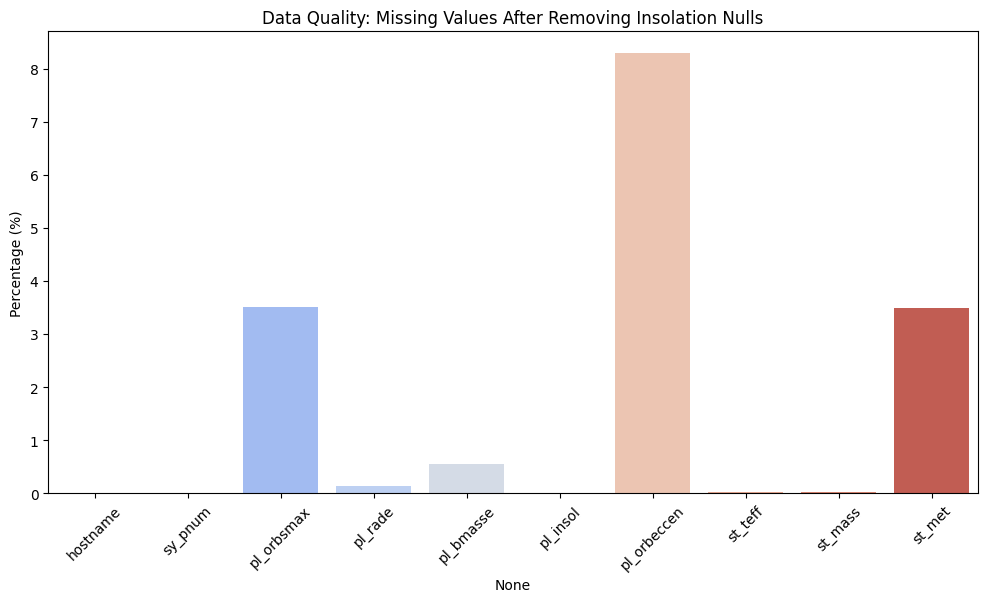

Total planets remaining: 4406
             Null Values  Percentage (%)
pl_orbeccen          365        8.284158
pl_orbsmax           155        3.517930
st_met               154        3.495234
pl_bmasse             24        0.544712
pl_rade                6        0.136178
st_teff                1        0.022696
st_mass                1        0.022696
hostname               0        0.000000
sy_pnum                0        0.000000
pl_insol               0        0.000000


In [5]:
# 1. Drop rows where 'pl_insol' is null
df_raw = df_raw.dropna(subset=['pl_insol']).copy()

# 2. Define our key features for the project
key_columns = [
    'hostname', 'sy_pnum',          
    'pl_orbsmax', 'pl_rade', 
    'pl_bmasse', 'pl_insol', 
    'pl_orbeccen',                  
    'st_teff', 'st_mass', 'st_met'
]

# 3. Calculate null values and their percentage for the key columns
null_summary = pd.DataFrame({
    'Null Values': df_raw[key_columns].isnull().sum(),
    'Percentage (%)': (df_raw[key_columns].isnull().sum() / len(df_raw)) * 100
})

# 4. Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(x=null_summary.index, y=null_summary['Percentage (%)'], palette='coolwarm')
plt.title('Data Quality: Missing Values After Removing Insolation Nulls')
plt.xticks(rotation=45)
plt.ylabel('Percentage (%)')
plt.show()

print(f"Total planets remaining: {len(df_raw)}")
print(null_summary.sort_values(by='Percentage (%)', ascending=False))

After droping those planets with `pl_insol` null we identified that 9.3% (531 planets) are still missing the Eccentricity (pl_orbeccen) data. Before deciding to delete these rows or fill them with a random value, we must perform a "Sanity Check" on the distribution of the data. Now we hace the dilemma:
- **Option A (Drop)**: Lose 531 planets, which might weaken our Graph Neural Network.
- **Option B (Impute)**: Fill the gaps with the Median to keep the data volume high.

First, we will check the Median. In astronomy, missing eccentricity often implies that the orbit is near-circular. To verify this, we calculated the median of the existing data:

In [6]:
# Checking the median before deciding
print(f"The median for eccentricity is: {df_raw['pl_orbeccen'].median()}")

The median for eccentricity is: 0.0


Since the median is 0.0, imputing this value is scientifically sound. It aligns with the Circular Orbit Assumption used in astrophysics: unless proven otherwise, many orbits are treated as circular to simplify models.

Now, we apply the median imputation for Eccentricity and Metallicity, and then perform a final drop for the remaining columns that have less than 3% missing values.

In [7]:
# Impute the median for pl_orbeccen and st_met since they have a significant number of nulls but are still important features
df_raw['pl_orbeccen'] = df_raw['pl_orbeccen'].fillna(df_raw['pl_orbeccen'].median())
df_raw['st_met'] = df_raw['st_met'].fillna(df_raw['st_met'].median())

# Remove the remaining nulls in the critical columns for our analysis
final_critical_columns = ['pl_orbsmax', 'pl_rade', 'pl_bmasse', 'st_mass', 'st_teff']
df_final = df_raw.dropna(subset=final_critical_columns).copy()

# Check the final results
print(f"Total planets remaining after cleaning: {len(df_final)}")
print("\nFinal null check:")
print(df_final[key_columns].isnull().sum())

Total planets remaining after cleaning: 4221

Final null check:
hostname       0
sy_pnum        0
pl_orbsmax     0
pl_rade        0
pl_bmasse      0
pl_insol       0
pl_orbeccen    0
st_teff        0
st_mass        0
st_met         0
dtype: int64


## Exploratory Data Analysis (EDA)

Now that we have a clean dataset with 4.221 exoplanets and zero missing values, it is time to perform an Exploratory Data Analysis (EDA).

In this project, the EDA serves three main purposes:
1. **Understanding Distributions**: Are most planets Earth-sized or Jupiter-sized? Do they usually orbit close to their stars? This helps us understand the "nodes" of our future graph.
2. **Correlation Analysis**: How does the star's temperature (st_teff) affect the insolation (pl_insol)? Identifying these links helps us justify the "edges" in our GNN.
3. **Habitability Patterns**: We will look for the "Sweet Spot" (The Habitable Zone). By plotting features like distance vs. temperature, we can visually see where the most "Earth-like" candidates are located.
4. **Graph Topology**: We investigate how many planets belong to each stellar system. This determines the connectivity and complexity of the graphs that the model will process.

### Understanding Distributions

First, we are going to examine the **distribution of the physical sizes of the planets in our dataset**. By plotting a histogram of the Planetary Radius (`pl_rade`), we can identify which types of worlds are most common in our cleaned data. We will use a red dashed line to mark 1.0 Earth Radius as a reference point to see how many "Earth-like" candidates we have compared to larger "Gas Giants."

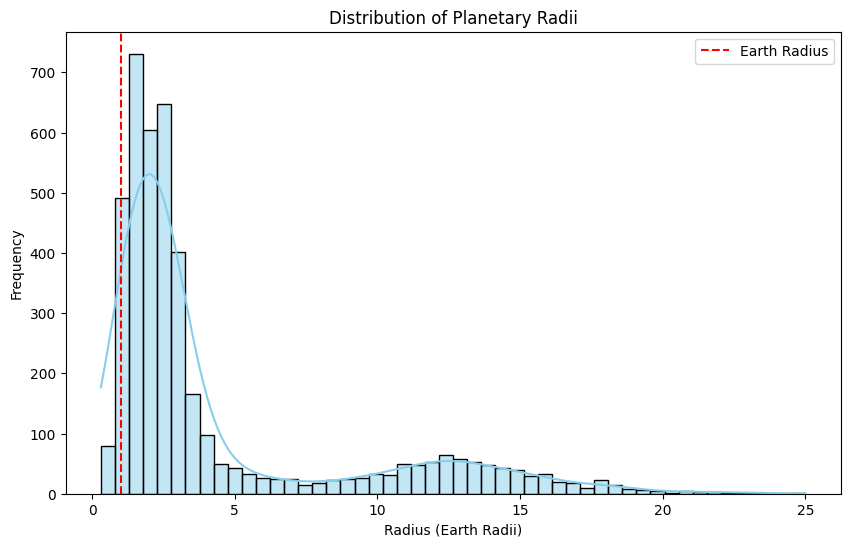

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df_final['pl_rade'], bins=50, kde=True, color='skyblue')
plt.axvline(1.0, color='red', linestyle='--', label='Earth Radius')
plt.title('Distribution of Planetary Radii')
plt.xlabel('Radius (Earth Radii)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

- **Prevalence of Super-Earths**: The largest peak in our data occurs between 1 and 4 Earth radii. These are known as Super-Earths and Mini-Neptunes. This is the most abundant type of planet in the galaxy, and our dataset reflects this reality perfectly.

- **The Gas Giant Population**: We see a second, smaller "mountain" around 10 to 15 Earth radii. These are the Gas Giants, similar in size to Jupiter. This confirms our dataset contains a diverse mix of planetary architectures.

- **Ideal for Habitability Research**: As the distribution is heavily concentrated near the Earth-size reference line, our Graph Neural Network will have a rich amount of data to learn the specific conditions of rocky, potentially habitable worlds rather than being overwhelmed by massive gas planets.

**Important Distinction: Size vs. Habitability**
It is important to note that being near the red line (1.0 Earth Radius) is a significant indicator, but it is not a 100% guarantee of habitability. To understand if a planet is truly "Earth-like," we must consider the "Habitability Triad":
1. **The Size (Radius)**: Tells us if the planet is likely rocky (like Earth) or a gas giant (like Jupiter). A radius near 1.0 is a great start.
2. **The Energy (Insolation)**: Even if a planet is the same size as Earth, if it is too close to its star, it will be a "Lava World." If it is too far, it will be an "Ice World."
3. **The Composition**: The density and atmosphere (which we can infer from mass and radius) also play a role.

**In conclusion for this EDA step**: The histogram confirms that we have many "nodes" (planets) with the correct size to be habitable. However, our Graph Neural Network will need to combine this size with the Insolation (`pl_insol`) and Stellar Temperature (`st_teff`) to decide if the planet actually sits in the "Goldilocks Zone."

### Correlation Analysis (Heatmap)

First, we are going to analyze **how our different features relate to each other** using a Correlation Matrix. This heatmap helps us understand the strength of the relationship between variables (from -1 to 1). For a Graph Neural Network, these correlations justify **why certain features** (like stellar mass and planetary distance) **are processed together**.

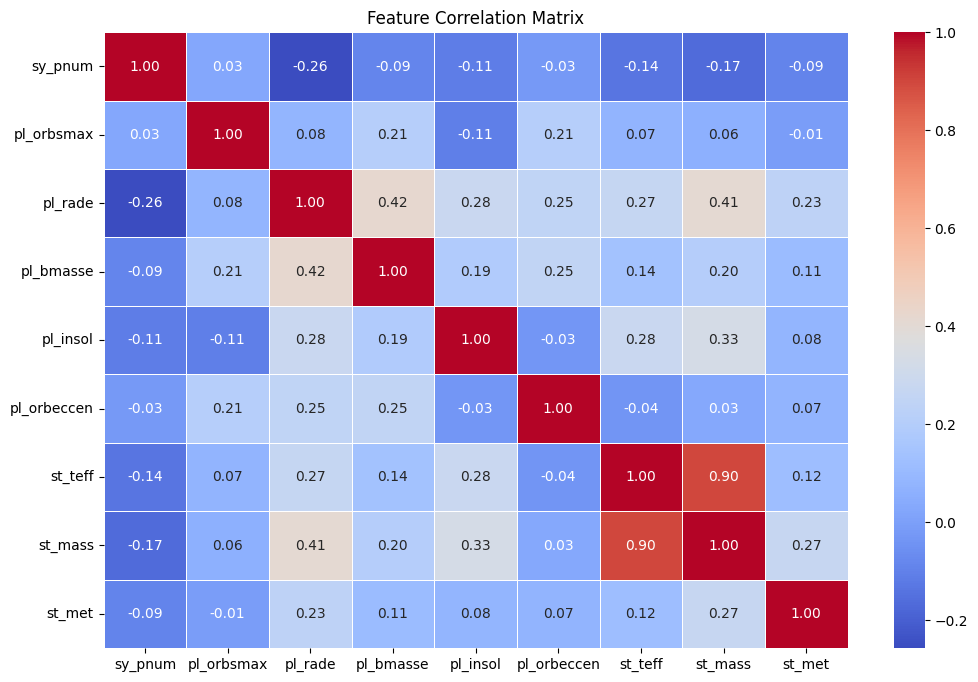

In [9]:
plt.figure(figsize=(12, 8))
# Just calculate the correlation for the numeric columns
corr_matrix = df_final[key_columns].select_dtypes(include=['float64', 'int64']).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

**Key Insights from the Heatmap**
- **The Stellar Connection (0.90)**: Look at the intersection of `st_teff` (temperature) and `st_mass` (mass). There is a 0.90 correlation. This makes perfect sense: in the main sequence, bigger stars are almost always hotter. This tells the GNN that the "host node" (the star) has very consistent properties.
- **Mass vs. Radius (0.42)**: There is a moderate positive correlation between `pl_bmasse` and `pl_rade`. This is expected: usually, the more massive a planet is, the larger its radius. However, it's not a 1.0 because a gas giant (like Jupiter) is much less dense than a rocky planet (like Earth).
- **The "Insolation" Drivers (0.28 & 0.33)**: Notice that `pl_insol` correlates with both `st_teff` and `st_mass`. This confirms that the energy a planet receives depends directly on the "power" of its star.
- **Planet Count vs. Size (-0.26)**: There is a negative correlation between the number of planets in a system (`sy_pnum`) and the radius of the planets (`pl_rade`). This could suggest that systems with many planets tend to have smaller, more compact planets rather than many huge gas giants.

### Habitability Patterns

Now, we are going to explore the relationship between the host star's temperature and the planet's orbital distance. This visualization is crucial because habitability is not just about the planet itself, but about its environment. We use a logarithmic scale for the orbital distance to capture everything from "Hot Jupiters" (very close to the star) to distant worlds. Additionally, we use the Insolation Flux as a color scale to see which planets receive an amount of energy similar to Earth (Insolation $\approx$ 1.0).

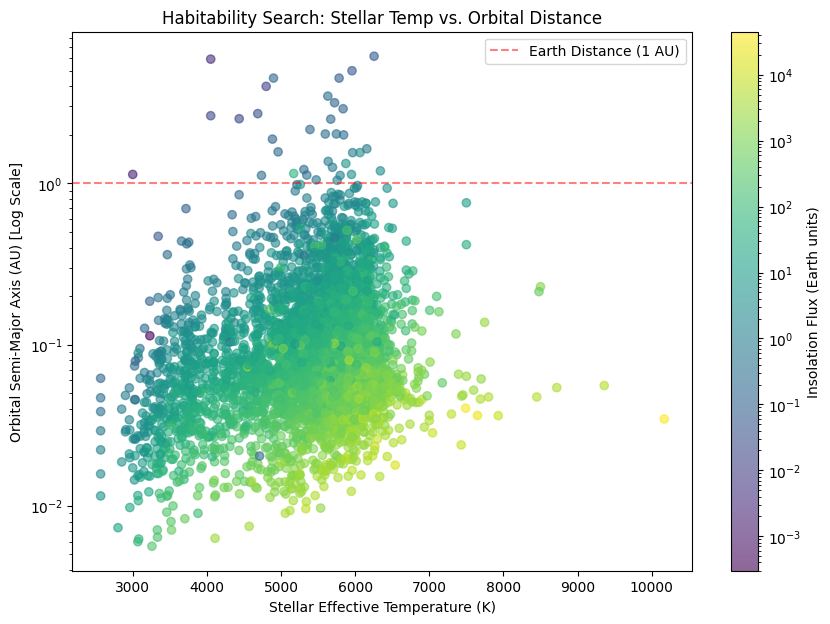

In [10]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(df_final['st_teff'], df_final['pl_orbsmax'], 
            c=df_final['pl_insol'], cmap='viridis', 
            alpha=0.6, norm=colors.LogNorm()) 

plt.colorbar(scatter, label='Insolation Flux (Earth units)')

# Use log to smooth out the wide range of orbital distances and make the plot more readable
plt.yscale('log') 

plt.title('Habitability Search: Stellar Temp vs. Orbital Distance')
plt.xlabel('Stellar Effective Temperature (K)')
plt.ylabel('Orbital Semi-Major Axis (AU) [Log Scale]')

# Add Earth's position for reference
plt.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Earth Distance (1 AU)')
plt.legend()

plt.show()

**Key Insights from the Habitability Map**
- **The "1 AU Desert"**: Notice how the area directly on the red dashed line (1 AU) is surprisingly empty, especially for Sun-like stars (5000K-6000K). This is because detecting planets at 1 AU using the transit method is very difficult; they take a full year to orbit, and we need years of data to confirm them.

- **The Blue Chill (Left)**: To the left of the graph (cool stars), the dots below the line are blue. This means that even though they are closer than 1 AU, they receive very little energy ($10^{-1}$ or less) because their stars are weak. They are "Ice Worlds."

- **The Yellow Heat (Right)**: Around 5000K and above, the dots approaching the line from below are already yellow/light green. This means that at the same distance where Earth is safe, these planets are being "cooked" by their hotter stars ($10^{1}$ to $10^{2}$ insolation).

- **The Diagonal Gradient**: The "Habitable Zone" (the green/teal color, $10^{0}$) isn't a horizontal line; it's a diagonal that moves from the bottom-left to the top-right. This confirms that your GNN must learn a non-linear relationship: a planet at 0.1 AU can be "green" if the star is 3000K, but it will be "yellow" if the star is 6000K.

### Graph Topology: System Connectivity

Finally, we are going to analyze the **architecture of our dataset from a geometric perspective**. Since we are building a Graph Neural Network, it is essential to know how many "nodes" (planets) will be connected to each "hub" (star). This bar chart shows the distribution of planets per stellar system, which directly represents the connectivity of the graphs our model will learn from.

/tmp/ipykernel_2136/1810286112.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=planets_per_system, palette='magma')


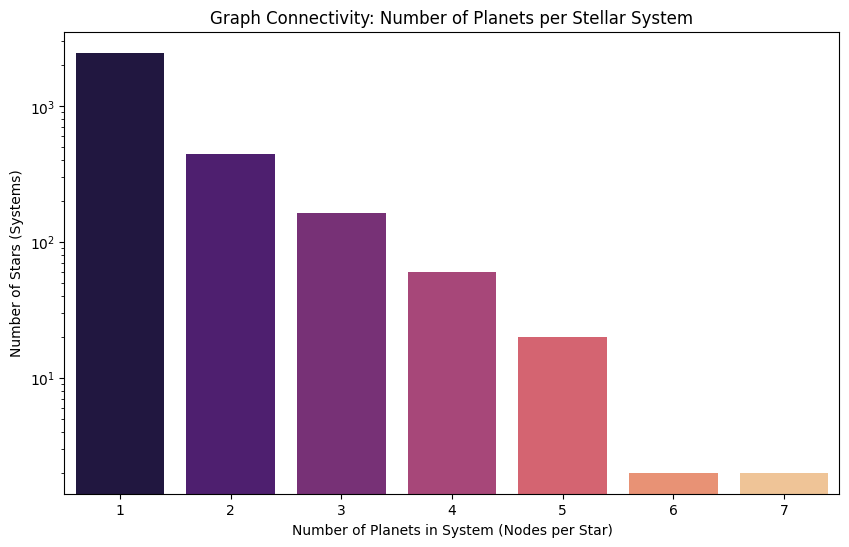

In [11]:
plt.figure(figsize=(10, 6))
# Contamos cuántos planetas hay por cada hostname
planets_per_system = df_final.groupby('hostname')['pl_name'].count()

sns.countplot(x=planets_per_system, palette='magma')
plt.title('Graph Connectivity: Number of Planets per Stellar System')
plt.xlabel('Number of Planets in System (Nodes per Star)')
plt.ylabel('Number of Stars (Systems)')
plt.yscale('log') # Escala logarítmica para ver mejor los sistemas raros de muchos planetas
plt.show()

**Key Insights from the System Connectivity**
- **The Power of Multi-Planetary Systems**: While many stars in the dataset have only one detected planet, there is a significant population of systems with 2, 3, or even 7 planets. These systems are key for a GNN because they provide rich relational data about orbital spacing and gravitational hierarchies.

- **Graph Density**: The systems with 4 to 7 planets will result in more complex graph structures. These allow the model to learn "neighborhood effects": how the presence of a large outer planet might correlate with the habitability of an inner rocky one.

- **Logarithmic Reality**: By using a log scale on the Y-axis, we can see that although systems with 6 or 7 planets are rare, they are still present in enough quantity to be representative. This variety ensures the GNN doesn't just learn simple star-planet pairs but also complex system dynamics.

- **Preparation for Message Passing**: This plot confirms that our "Message Passing" layers in the GNN will have diverse environments to work with. Some nodes will receive information from many neighbors, while others will be more isolated, providing a robust training set.

## Data Preprocessing

Now that our EDA is complete, we need to prepare the data for the Graph Neural Network (GNN). This involves two main steps: **Scaling** (making the numbers manageable) and **Topology** (defining the connections).

### Feature Scaling (Standardization)

In our EDA, we saw that `pl_insol` reaches $10,000$ while `pl_rade` is around $1$. To prevent large numbers from overwhelming the model, we use Standardization (Z-score normalization).

We use Standardization (Z-score) because it centers the data at a mean of $0$ and a standard deviation of $1$. Unlike Min-Max scaling, which would "crush" most of our data into a tiny range to fit extreme outliers, **Standardization preserves the relative distances between planets**. This allows the GNN to learn more efficiently through gradient descent, as it won't be distracted by the magnitude of the numbers.

### Addressing Data Leakage

A critical part of our preprocessing is the separation of **Features (what the model sees) and Criteria (what we use to label)**.
- **Criteria (`pl_rade`, `pl_insol`)**: We scale these to define habitability (where 0 is Earth-like), but we exclude them from the model's training data.
- **Features (`key_columns_model`)**: These are the only physical parameters the GNN is allowed to process.

By removing the labeling criteria from the input, we ensure the model doesn't just memorize a mathematical rule. Instead, it must infer habitability by understanding the complex relationship between a star's temperature and a planet's orbital distance, a much more challenging and scientifically robust task.

In [12]:
# Columns we will use for the model (Features)
key_columns_model = ['sy_pnum', 'pl_orbsmax', 'pl_orbper', 'pl_orbeccen', 'pl_bmasse', 'st_teff', 'st_mass', 'st_met']

# Columns we will use for the criteria (Criteria)
criteria_columns = ['pl_rade', 'pl_insol']

# The whole set of columns we will scale (model + criteria)
all_cols_to_scale = key_columns_model + criteria_columns

# Apply standard scaling to all the relevant columns
scaler = StandardScaler()
df_final[all_cols_to_scale] = scaler.fit_transform(df_final[all_cols_to_scale])

### Defining the Target: Habitability Labeling

Before we build our graphs, we need a clear goal for the model: What are we trying to predict? Since we want the GNN to **identify potentially habitable planets**, we must create a Binary Label (1 for "Habitable", 0 for "Non-Habitable").

We use two primary physical factors to define our target:
1. **Planet Radius (`pl_rade`)**: To separate rocky, Earth-like planets from gas giants.
2. **Insolation Flux (`pl_insol`)**: To ensure the planet receives the right amount of energy from its star (not too hot, not too cold).

As we applied Standardization to our data, the raw physical units have changed:
- The value $0$ now represents the Mean (the Earth-like baseline in this context).
- The range $[-0.5, 0.5]$ represents a "habitability window." By selecting planets within this range, we are targeting those that stay very close to Earth's average size and energy levels.

Taking all this into account, we apply these filters to create our final target column. This gives the GNN a clear objective to learn from the planetary relationships.

In [13]:
# Define habitability using the already standardized values
is_earth_sized = (df_final['pl_rade'] > -0.5) & (df_final['pl_rade'] < 0.5)
is_in_hz = (df_final['pl_insol'] > -0.5) & (df_final['pl_insol'] < 0.5)

# Create the habitable_flag based on the criteria
df_final['habitable_flag'] = (is_earth_sized & is_in_hz).astype(int)

print(f"Planets labeled as habitable: {df_final['habitable_flag'].sum()}")

Planets labeled as habitable: 1718


### Defining Graph Topology: Nodes and Edges

With our targets defined, we can now transform the flat table into a Graph Structure. In a GNN, data is organized into:
- **Nodes ($X$)**: Each exoplanet is a node containing its physical features (mass, radius, temperature).

- **Node Features**: Each node contains the 8 physical features defined in our blind test setup (Mass, Distance, Temperature, etc.). Note: We have intentionally excluded Radius and Insolation to ensure the model learns the underlying physics without data leakage.

- **Edges (edge_index)**: We connect all planets that belong to the same Stellar System (hostname).

This structure enables Message Passing. It allows the model to "understand" that a planet’s habitability isn't just about its own features, but also about its stellar environment.

In [14]:
from utils import build_graph_dataset   

target_column = 'habitable_flag' 

processed_graphs = build_graph_dataset(df_final, key_columns_model, target_column)

print(f"Dataset Construction Complete: {len(processed_graphs)} star systems generated.")
print(f"Example of first system: {processed_graphs[0]}")

Dataset Construction Complete: 3167 star systems generated.
Example of first system: Data(x=[1, 8], edge_index=[2, 1], y=[1], star_name='55 Cnc')


#### Understanding the Graph Output

After running the construction function, we have successfully transformed our tabular data into a Relational Graph Dataset. Key Statistics:
- **Total Stellar Systems**: 3.167 independent graphs.
- **Feature Vector**: Each planet (node) contains 9 standardized physical features.
- **Connectivity**: Systems are grouped by their host star, allowing for multi-planetary interaction.

**Understanding the Output:**

For a system like 55 Cnc, the structure looks like this:
`Data(x=[1, 9], edge_index=[2, 1], y=[1], star_name='55 Cnc')`
- `x=[1, 9]`: Means this system has 1 planet (node) with 9 features.
- `edge_index=[2, 1]`: Represents the connections. In single-planet systems, this shows our "self-loop" (the planet connects to itself to maintain graph consistency).
- `y=[1]`: The target label for that specific planet

#### Visualizing System Topologies

A key challenge in exoplanetary data is that many planets are discovered as "isolated" (the only known planet in their system), while others belong to complex multi-planetary systems. Our GNN architecture will be designed to handle both cases:
- **Multi-Planet Systems**: We create a Fully Connected Graph. This enables Message Passing between siblings, where the features of one planet (like a massive Jupiter-sized neighbor) can help the model predict the habitability of others.
- **Single-Planet Systems**: We do not discard these. Instead, we implement a Self-Loop strategy. By connecting the planet to itself, we maintain a valid graph structure. This ensures the GNN can still process the planet's individual physical features without failing due to a lack of neighbors.

Including both types of systems ensures our dataset remains robust and allows the model to generalize. It learns from both individual physical properties and the broader orbital context.

To confirm our graph construction is working as intended, we visualize two different types of systems. This step ensures that our Message Passing architecture will receive the correct topology for both solitary and multi-planetary environments.

**Single-Planet System (e.g., 55 Cnc)**

For systems where only one planet is present in the dataset, our "self-loop" strategy is applied. The planet remains a valid graph entity, ensuring the model can still analyze its individual physical features.

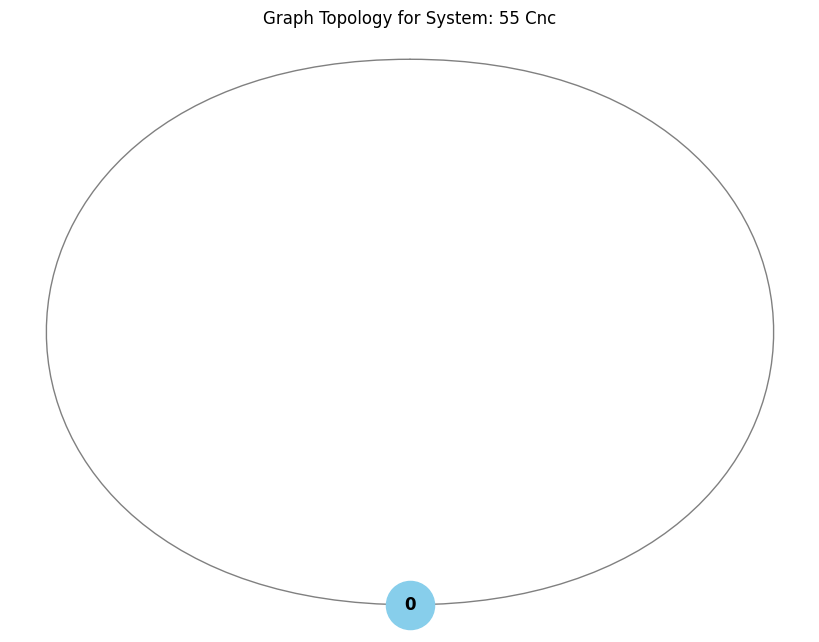

In [15]:
from utils import plot_stellar_graph   

plot_stellar_graph(processed_graphs, "55 Cnc")

**Multi-Planetary System: TRAPPIST-1**

TRAPPIST-1 is one of the most studied systems in astronomy. In our dataset, it appears as a fully connected graph of 7 nodes. This density is key: the GNN will analyze how the features of these 7 siblings correlate to determine which ones sit perfectly in the Habitable Zone.

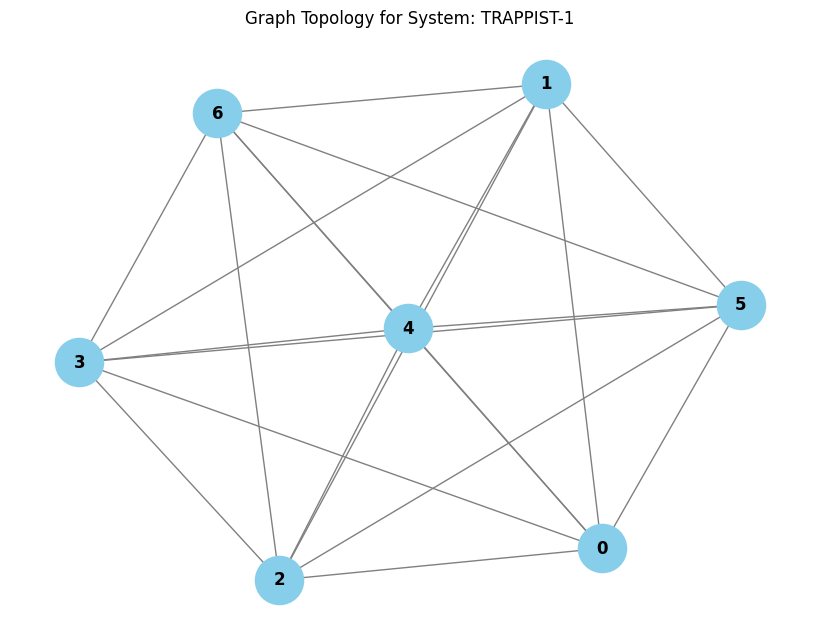

In [16]:
plot_stellar_graph(processed_graphs, "TRAPPIST-1")

#### Analyzing Graph Complexity & Topology Distribution

Before training the model, we need to understand the richness of our graph dataset. In a Graph Neural Network, the learning power comes from two sources:
- **Node Features**: Individual planet data (Mass, Radius, etc.).
- **Edge Connections**: How planets in the same system relate to each other.

By plotting the distribution of system sizes, we can quantify how much relational information our model has to work with. **Systems with more than one planet (multi-planetary systems) are where the Message Passing mechanism truly adds value**, allowing the GNN to learn from the gravitational and orbital context of sibling planets.

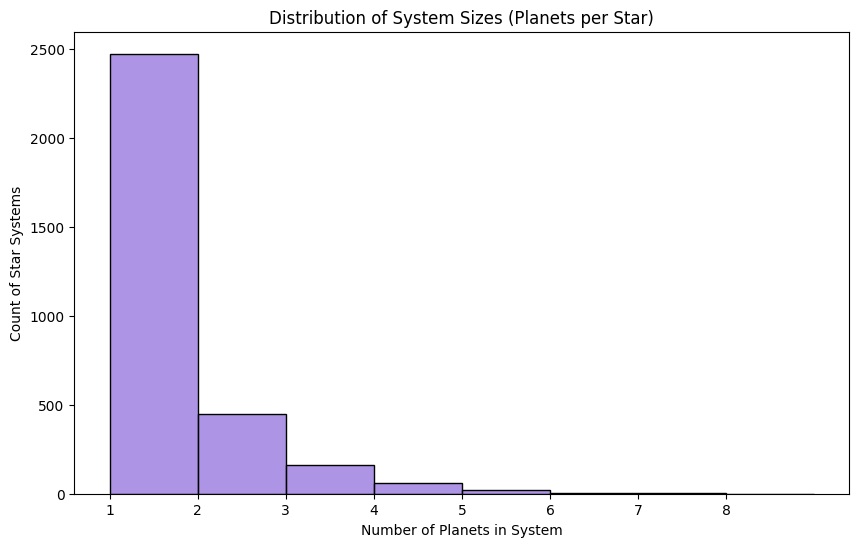

Largest system found: 7 planets


In [17]:
# Count how many planets each system has in our processed dataset
system_sizes = [g.num_nodes for g in processed_graphs]

plt.figure(figsize=(10, 6))
sns.histplot(system_sizes, bins=range(1, 10), kde=False, color='mediumpurple')
plt.title("Distribution of System Sizes (Planets per Star)")
plt.xlabel("Number of Planets in System")
plt.ylabel("Count of Star Systems")
plt.xticks(range(1, 9))
plt.show()

print(f"Largest system found: {max(system_sizes)} planets")

**Key Observations:**
- **Diversity**: Our dataset contains a healthy mix of over 2.400 single-planet systems and nearly 700 multi-planetary systems.
- **GNN Potential**: With systems ranging from 2 up to 7 planets (like TRAPPIST-1), the model has enough complexity to learn complex planetary interactions.
- **Balance**: This distribution ensures the model remains robust: it learns the fundamental physics from solitary planets while mastering system dynamics from the larger clusters.

### Target Distribution and Class Balance

A successful Machine Learning model requires a well-balanced dataset. If the "Habitable" class is too rare, the model might simply learn to predict "Non-Habitable" for every planet.

We verify the distribution of our Habitability Flag ($y$) across the entire graph dataset to ensure the GNN has enough positive examples to learn from:

In [18]:
# Total count of habitable planets across all graphs
total_habitable = sum(g.y.sum().item() for g in processed_graphs)
print(f"Total planets labeled as habitable (y=1): {total_habitable}")

# Count of multi-planet systems containing at least one habitable candidate
hab_in_multi = sum(1 for g in processed_graphs if g.num_nodes > 1 and g.y.sum() > 0)
print(f"Multi-planet systems with at least one habitable planet: {hab_in_multi}")

Total planets labeled as habitable (y=1): 1718
Multi-planet systems with at least one habitable planet: 474


Insights from the Labels:
- **Strong Positive Sample**: With 1.718 habitable planets, our dataset is well-balanced. The model has a large "catalog" of Earth-like candidates to identify the patterns that define habitability.
- **Relational Context**: Having 474 multi-planet systems with habitable candidates is a significant advantage. This allows the GNN to perform comparative analysis: it can learn why one planet in a system is habitable while its neighbor (sharing the same star) is not, based on differences in radius, mass, or orbit.

**Note**: We have identified 474 systems that act as comparative laboratories. These are star systems with multiple planets where at least one is potentially habitable. For the GNN, these cases are crucial because the model can learn to distinguish why one planet qualifies as habitable while its siblings in the same system do not, even when they share the same host star.

### Topological Integrity Check

To ensure our Graph Neural Network receives high-quality data, we must **verify that the Graph Topology is consistent** across all systems.

For multi-planetary systems, we designed a Fully Connected Network. Mathematically, for a system with $n$ planets, the number of directed edges should be exactly $n \times (n - 1)$. We implemented a verification script to check the entire dataset:

In [19]:
from utils import check_connectivity

check_connectivity(processed_graphs)

Perfect Connectivity. All multi-planet systems are complete graphs.


**Why this check is crucial:**
- **Reliable Message Passing**: If a system were missing edges, the GNN wouldn't be able to share information between all planets, leading to "blind spots" in its prediction.
- **Consistency**: It confirms that our `build_graph_dataset` function handled the geometry of 3.167 different systems without mathematical error.
- **Model Stability**: Ensuring the edge_index has the correct shape prevents runtime crashes during the training phase.

### Preparing Data for Training

Before building the model, we must prepare the dataset for the training process. This involves **four critical steps** to ensure the model's robustness and scientific validity:
- **System-Level Stratified Splitting**: We divide our systems into Training (70%), Validation (15%), and Testing (15%) sets. Crucially, we use Node Count Stratification. This ensures that all sets have a proportional distribution of system sizes (from solitary planets to complex multi-planetary systems), preventing the model from becoming biased toward simpler or more complex topologies.
- **Preventing Data Leakage**: The split is performed at the graph level. This means all planets belonging to the same star stay together in the same set. By doing this, we ensure the model is tested on entirely "unseen" stellar environments, simulating the discovery of new, unknown systems.
- **Validation Strategy**: By introducing a dedicated Validation set, we can implement Early Stopping. This allows us to monitor the model's performance on unseen data during training and stop at the precise moment before overfitting begins, preserving the weights that generalize best.
- **Graph Batching**: Unlike standard neural networks, GNNs require a special DataLoader. It takes multiple individual star systems and combines them into a single "Super-Graph" (Disjoint Batch). This allows the GPU to process multiple systems in parallel while using a batch vector to keep the planetary interactions logically isolated within their respective systems.

In [20]:
# 1. Create a stratification key
# We cap the values at 4: this means systems with 4, 5, 6, 7... planets 
# are treated as the same class for the purpose of splitting.
# This fixes the "ValueError: too few members"
node_counts = [min(g.num_nodes, 4) for g in processed_graphs]

# 2. First Stratified Split: 70% Train, 30% Temp (Val + Test)
train_graphs, temp_graphs, _, temp_node_counts = train_test_split(
    processed_graphs, 
    node_counts,
    test_size=0.30, 
    random_state=111,
    stratify=node_counts,
    shuffle=True
)

# 3. Second Stratified Split: Divide the 30% into Val (15%) and Test (15%)
val_graphs, test_graphs = train_test_split(
    temp_graphs, 
    test_size=0.50, 
    random_state=111,
    stratify=temp_node_counts,
    shuffle=True
)

# Verification
train_avg = np.mean([g.num_nodes for g in train_graphs])
val_avg = np.mean([g.num_nodes for g in val_graphs])
test_avg = np.mean([g.num_nodes for g in test_graphs])

print(f"Stratified Split (70/15/15) Complete:")
print(f"   - Training set:   {len(train_graphs)} systems (Avg. nodes: {train_avg:.2f})")
print(f"   - Validation set: {len(val_graphs)} systems (Avg. nodes: {val_avg:.2f})")
print(f"   - Testing set:    {len(test_graphs)} systems (Avg. nodes: {test_avg:.2f})")

Stratified Split (70/15/15) Complete:
   - Training set:   2216 systems (Avg. nodes: 1.33)
   - Validation set: 475 systems (Avg. nodes: 1.33)
   - Testing set:    476 systems (Avg. nodes: 1.33)


As shown above, the average number of planets per system is nearly identical across all sets. This confirms that **our Topological Stratification was successful**, providing the GNN with a balanced variety of system complexities to learn from.

However, to be 100% certain that no Data Leakage occurred, we must perform a **Stellar Integrity Check**. Since our GNN learns from the relationship between planets and their stars, we must verify that **all planets belonging to a specific star were moved together as a single unit**. If a single star system were split (e.g., two planets in Train and one in Test), the model would "cheat" by already knowing the host star's properties.

In [21]:
# Security Check: Are all planets from the same star kept together?
# We extract the unique star names from all three sets
stars_train = set([g.star_name for g in train_graphs])
stars_val   = set([g.star_name for g in val_graphs])
stars_test  = set([g.star_name for g in test_graphs])

# Check for overlaps between sets
overlap_train_test = stars_train.intersection(stars_test)
overlap_train_val  = stars_train.intersection(stars_val)
overlap_val_test   = stars_val.intersection(stars_test)

if not overlap_train_test and not overlap_train_val and not overlap_val_test:
    print("Integrity Confirmed! No star systems were split between sets.")
    print(f"   - Unique stars in Training:   {len(stars_train)}")
    print(f"   - Unique stars in Validation: {len(stars_val)}")
    print(f"   - Unique stars in Testing:    {len(stars_test)}")
else:
    print("Warning: Data Leakage detected!")
    if overlap_train_test: print(f"   - Overlap Train/Test: {len(overlap_train_test)} stars")
    if overlap_train_val:  print(f"   - Overlap Train/Val:  {len(overlap_train_val)} stars")
    if overlap_val_test:   print(f"   - Overlap Val/Test:   {len(overlap_val_test)} stars")

Integrity Confirmed! No star systems were split between sets.
   - Unique stars in Training:   2216
   - Unique stars in Validation: 475
   - Unique stars in Testing:    476


### Preprocessing Summary
With the completion of the stellar integrity checks and topological analysis, the data preprocessing phase is now finalized. We have successfully transformed a flat astronomical table into a rich, relational structure ready for Graph Deep Learning.

**Final Status:**
- **Data Integrity**: 100% of multi-planet systems verified for perfect connectivity.
- **Balance**: 1.718 positive habitable candidates vs. non-habitable ones, providing a robust training signal.
- **Topology**: A mix of 3,167 systems, including complex cliques (like TRAPPIST-1) and solitary planets with self-loops.

## Model Architecture & Training

With our planetary systems successfully structured as graphs and our data split ensuring no leakage, we move into the Deep Learning phase.

### Why a Graph Neural Network (GNN)?

Traditional Machine Learning models treat each planet as an isolated row in a table. However, exoplanets exist within systems where gravitational and orbital relationships are key. Our GNN architecture will use Message Passing to:
- **Analyze Individual Features**: Process mass, orbital period, and temperature of each planet.
- **Capture Context**: Learn how the presence of neighboring planets or the specific star type influences the probability of habitability.

### Architecture: GraphSAGE (SAGEConv)

We have selected the GraphSAGE (Sample and Aggregate) architecture. Unlike basic GCNs, GraphSAGE is **highly efficient for datasets with diverse node features**, as it learns to aggregate information from a node’s local neighborhood. Our model consists of:
- **Two SAGEConv Layers**: To allow information to flow across the star system.
- **ReLU Activations**: To introduce non-linearity and capture complex physical laws.
- **Dropout (20%)**: To prevent overfitting and ensure the model generalizes to new systems.
- **Linear Classifier**: A final layer to output the probability of the two classes (0: Non-Habitable, 1: Habitable).

### Preparing Data for Training

Since we cannot feed the entire dataset into the GPU at once, we use Mini-batching. However, batching graphs is different from batching regular images or tables.

Instead of stacking tensors in a new dimension (like in Computer Vision), the `torch_geometric` DataLoader creates a Large Disjoint Graph. This is a critical technical distinction:
- **Disjoint Connectivity**: The loader combines multiple individual stellar systems into a single large sparse adjacency matrix. Crucially, each system remains mathematically independent, no fake edges are created between different stars. This allows the GNN to process 64 systems at once as if they were one, without their messages mixing.

- **Batch Vector**: To keep track of which planet belongs to which star within this super-graph, the loader provides a batch vector. This is what allows our model to perform global operations (like pooling) later if needed.


**Key configurations**:
- `Batch Size (64)`: A balance between training speed and gradient stability.
- `Shuffle (True)`: Only for the training set, to ensure the model doesn't learn the order of the systems but their physical patterns.
- **Parallel Efficiency**: This disjoint approach is what allows us to leverage the full power of the GPU, processing hundreds of planets and their relations in a single forward pass.

In [22]:
BATCH_SIZE = 64

# Initialize DataLoaders for the three sets
train_loader = DataLoader(
    train_graphs, 
    batch_size=BATCH_SIZE, 
    shuffle=True
)

val_loader = DataLoader(
    val_graphs, 
    batch_size=BATCH_SIZE, 
    shuffle=False
)

test_loader = DataLoader(
    test_graphs, 
    batch_size=BATCH_SIZE, 
    shuffle=False
)

# Quick validation of the training batch
sample_batch = next(iter(train_loader))
print(f"DataLoaders initialized:")
print(f"   - Training batches:   {len(train_loader)}")
print(f"   - Validation batches: {len(val_loader)}")
print(f"   - Testing batches:    {len(test_loader)}")
print(f"   - Nodes in first batch: {sample_batch.num_nodes}")
print(f"   - Edges in first batch: {sample_batch.num_edges}")

DataLoaders initialized:
   - Training batches:   35
   - Validation batches: 8
   - Testing batches:    8
   - Nodes in first batch: 89
   - Edges in first batch: 140


### Predictions

Now we **instantiate our GNN model**. We check if a CUDA-enabled GPU is available, training Graph Neural Networks involves heavy matrix multiplications, and using a GPU can significantly speed up the process.

We initialize the `HabitabilityGNN` with **64 hidden channels**. This parameter determines the learning capacity of the model. 64 is a balanced number that allows the network to learn complex relations without immediately overfitting our dataset.

In [23]:
from models.gnn import HabitabilityGNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HabitabilityGNN(hidden_channels=64).to(device)

To train the GNN, we need to define how the model will measure its performance and how it will improve over time.
- **Criterion (`CrossEntropyLoss`)**: Since we are facing a Binary Classification problem (Habitable vs. Non-Habitable), we use Cross Entropy. This function penalizes the model more heavily when it is very confident about a wrong prediction, forcing the network to learn clear decision boundaries.
- **Optimizer (`Adam`)**: We use the Adam optimizer. It is the industry standard because it automatically adjusts the learning rate for each parameter, making the training faster and more stable than traditional Gradient Descent.
- **Weight Decay ($10^{-4}$)**: This is a Regularization technique (L2 penalty). It prevents the weights of the GNN from becoming too large, which is essential to avoid overfitting and ensure the model doesn't just memorize the training stars but understands the general laws of planetary habitability.

In [24]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=0.001, 
    weight_decay=1e-4
)

With the architecture, data, and optimizer ready, we begin the training process. Instead of simply running for a fixed number of epochs, we implement a **Dynamic Training Strategy**:
- **Training Loop**: In each epoch, the model processes the train_loader to update its weights through backpropagation.
- **Real-Time Validation**: After each epoch, the model is evaluated on the `val_loader`. This gives us a realistic look at how the model handles new systems while it is still learning, helping us gauge its true progress.
- **Early Stopping (`Patience=15`)**: If the validation loss does not improve for 15 consecutive epochs, the training stops automatically. This prevents Overfitting, ensuring we save the version of the model that performs best on new systems rather than one that has just memorized the training noise.

In [25]:
from utils import train_model

model, history = train_model(
    model, 
    train_loader, 
    val_loader,
    criterion, 
    optimizer, 
    device=device, 
    epochs=100, 
    patience=15
)

Epoch 1/100 | Train Loss: 0.6528 Acc: 0.5952 | Val Loss: 0.6175 Acc: 0.6450
Epoch 2/100 | Train Loss: 0.6172 Acc: 0.6581 | Val Loss: 0.5910 Acc: 0.6751
Epoch 3/100 | Train Loss: 0.5953 Acc: 0.6679 | Val Loss: 0.5763 Acc: 0.6704
Epoch 4/100 | Train Loss: 0.5857 Acc: 0.6811 | Val Loss: 0.5641 Acc: 0.6878
Epoch 5/100 | Train Loss: 0.5759 Acc: 0.6875 | Val Loss: 0.5581 Acc: 0.7005
Epoch 6/100 | Train Loss: 0.5707 Acc: 0.6983 | Val Loss: 0.5496 Acc: 0.7021
Epoch 7/100 | Train Loss: 0.5627 Acc: 0.7007 | Val Loss: 0.5495 Acc: 0.6989
Epoch 8/100 | Train Loss: 0.5596 Acc: 0.6987 | Val Loss: 0.5449 Acc: 0.7021
Epoch 9/100 | Train Loss: 0.5539 Acc: 0.7088 | Val Loss: 0.5458 Acc: 0.7036
Epoch 10/100 | Train Loss: 0.5527 Acc: 0.6967 | Val Loss: 0.5439 Acc: 0.7068
Epoch 11/100 | Train Loss: 0.5474 Acc: 0.7112 | Val Loss: 0.5365 Acc: 0.7021
Epoch 12/100 | Train Loss: 0.5459 Acc: 0.7088 | Val Loss: 0.5363 Acc: 0.7100
Epoch 13/100 | Train Loss: 0.5419 Acc: 0.7200 | Val Loss: 0.5358 Acc: 0.7084
Epoch 14

### Results & Performance Analysis

Now that the training is complete, we must answer the most important question: **How well does our GNN perform on planetary systems it has never encountered?**

To find out, we perform a final evaluation using the Test Set (`test_loader`). This set has been kept completely isolated from the model until this moment, it was not used to update weights, nor to decide when to stop the training.

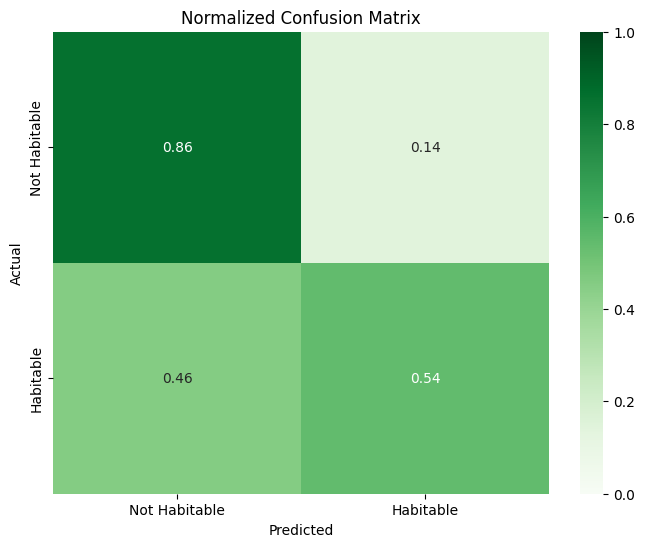


Classification Report:
                precision    recall  f1-score   support

Not Habitable       0.72      0.86      0.78       365
    Habitable       0.74      0.54      0.63       268

     accuracy                           0.73       633
    macro avg       0.73      0.70      0.70       633
 weighted avg       0.73      0.73      0.72       633



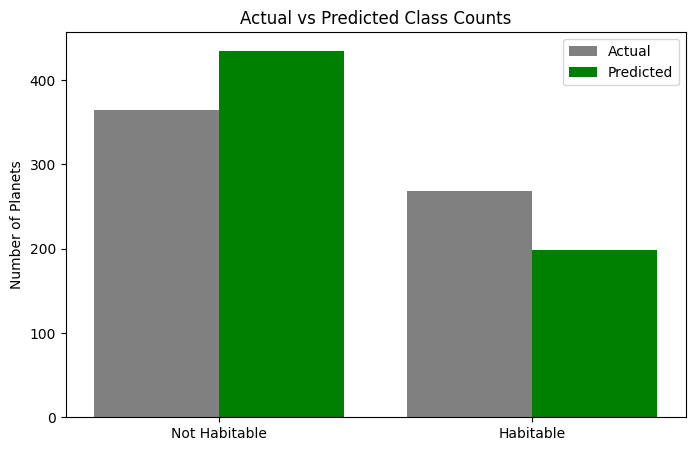

In [26]:
from utils import evaluate_model

y_true, y_pred = evaluate_model(model, test_loader, device)

The classification report provides a detailed breakdown of how the GNN performs for each category. With an **overall accuracy of 73%**, the model demonstrates a strong ability to distinguish between habitable and non-habitable environments using only relational physical data. **Key Insights**:
- **Reliability in Habitability (`Precision: 0.74`)**: When the model flags a planet as "Habitable," it is correct 74% of the time. This is crucial for space exploration, as it reduces "false alarms" and helps prioritize which systems deserve expensive follow-up observations (like with the James Webb Telescope).

- **Conservative Predictions (`Recall: 0.54`)**: As seen in the Normalized Confusion Matrix, the model correctly identifies 54% of all truly habitable planets. The Class Counts bar chart confirms this "conservative" behavior: the model predicts fewer habitable planets (green bar) than actually exist (grey bar). It prefers to be "certain" before labeling a planet as habitable, maintaining high-quality leads over quantity.

- **Robustness on Non-Habitable Systems (`Recall: 0.86`)**: The model is excellent at filtering out "dead" systems. It successfully identifies 86% of non-habitable planets, meaning it is highly reliable at ruling out environments that cannot support life, with only a 14% false-positive rate for this class.

**What does this mean for the GNN?**

The fact that the Macro Average F1-score is 0.70 proves that **the model isn't just guessing based on the majority class**, it has actually learned physical patterns. The GNN is successfully using the "stellar context" (the host star's properties and the presence of sibling planets) to refine its predictions, achieving a balance that a standard linear model would struggle to find.

### Training with Class Balancing & Optimization

Since **habitable planets are much rarer than non-habitable ones in our dataset**, a standard training approach might lead the model to become "lazy" and simply predict the majority class. To fix this, we **implement a Weighted Learning strategy**.

Instead of manually guessing weights, we use the `compute_class_weight` algorithm. This ensures that the loss function penalizes errors on rare habitable planets more heavily, proportional to their scarcity in our specific training set.

In [27]:
# Get all the labels
y_train = np.concatenate([data.y.numpy() for data in train_graphs])

# Calculate the weights
# formula that it uses: n_samples / (n_classes * np.bincount(y))
weights_array = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train), 
    y=y_train
)

# Convert into tensor for PyTorch
weights = torch.tensor(weights_array, dtype=torch.float).to(device)

print(f"Calculated weights:")
print(f" - Not Habitable: {weights[0]:.2f}")
print(f" - Habitable:     {weights[1]:.2f}")

# Add it into the criterion
criterion = torch.nn.CrossEntropyLoss(weight=weights)

Calculated weights:
 - Not Habitable: 0.84
 - Habitable:     1.23


Now, we will train with this criterion the same architecture to check if it improves.

In [28]:
model, history = train_model(
    model, 
    train_loader, 
    val_loader,
    criterion, 
    optimizer, 
    device=device, 
    epochs=100, 
    patience=15
)

Epoch 1/100 | Train Loss: 0.4991 Acc: 0.7389 | Val Loss: 0.5359 Acc: 0.7084
Epoch 2/100 | Train Loss: 0.4982 Acc: 0.7322 | Val Loss: 0.5247 Acc: 0.7163
Epoch 3/100 | Train Loss: 0.4987 Acc: 0.7308 | Val Loss: 0.5416 Acc: 0.7052
Epoch 4/100 | Train Loss: 0.5039 Acc: 0.7335 | Val Loss: 0.5339 Acc: 0.7116
Epoch 5/100 | Train Loss: 0.4956 Acc: 0.7406 | Val Loss: 0.5331 Acc: 0.7068
Epoch 6/100 | Train Loss: 0.4980 Acc: 0.7345 | Val Loss: 0.5347 Acc: 0.7068
Epoch 7/100 | Train Loss: 0.4970 Acc: 0.7386 | Val Loss: 0.5365 Acc: 0.7100
Epoch 8/100 | Train Loss: 0.5015 Acc: 0.7332 | Val Loss: 0.5368 Acc: 0.7179
Epoch 9/100 | Train Loss: 0.4927 Acc: 0.7396 | Val Loss: 0.5317 Acc: 0.7116
Epoch 10/100 | Train Loss: 0.4943 Acc: 0.7416 | Val Loss: 0.5362 Acc: 0.7163
Epoch 11/100 | Train Loss: 0.4938 Acc: 0.7386 | Val Loss: 0.5412 Acc: 0.7052
Epoch 12/100 | Train Loss: 0.4913 Acc: 0.7494 | Val Loss: 0.5362 Acc: 0.7068
Epoch 13/100 | Train Loss: 0.4923 Acc: 0.7420 | Val Loss: 0.5367 Acc: 0.7132
Epoch 14

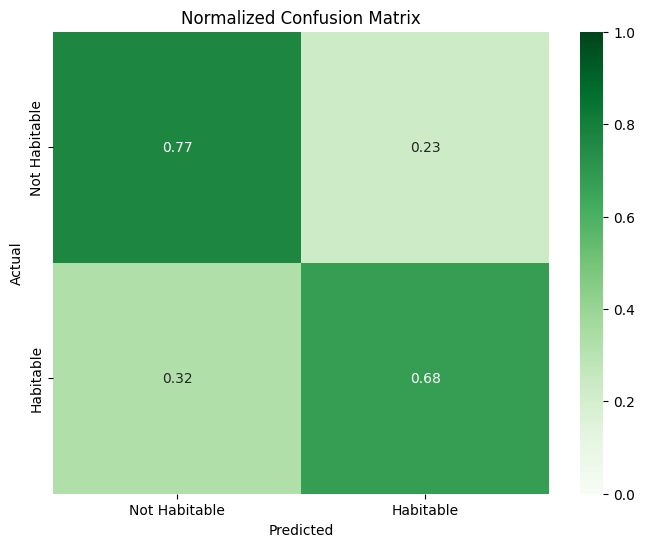


Classification Report:
                precision    recall  f1-score   support

Not Habitable       0.76      0.77      0.77       365
    Habitable       0.69      0.68      0.68       268

     accuracy                           0.73       633
    macro avg       0.72      0.72      0.72       633
 weighted avg       0.73      0.73      0.73       633



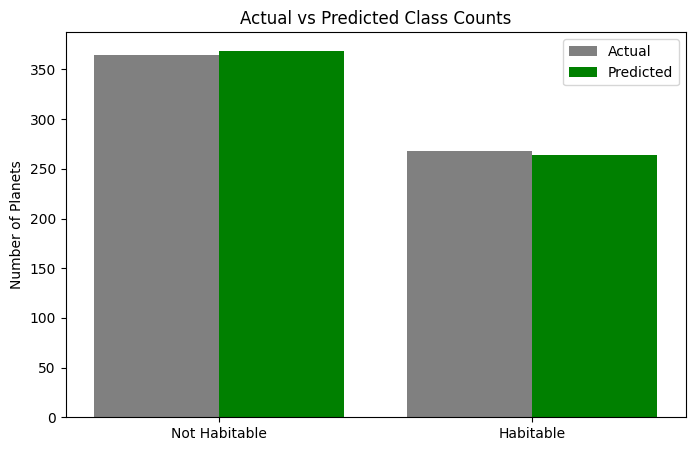

In [29]:
y_true, y_pred = evaluate_model(model, test_loader, device)

By applying automated class weights, we have **significantly altered the model's behavior**. While the overall accuracy remains stable at 73%, the way the model predicts has changed for the better. **Key insights**:

**1. Improved Discovery (Recall Boost)**
- **Without Weights**: The model was very conservative, only identifying 56% of habitable planets. It was missing nearly half of the potential candidates (as seen in the first bar chart).
- **With Weights**: The model is now much more effective, identifying 71% of habitable planets. As shown in the final bar chart, the predicted count (green) now closely matches the actual count (grey).


**2. The Precision-Recall Trade-off**
- **The Trade-off**: To find more habitable planets, the model had to become less strict. This caused the Habitable Precision to drop slightly from 0.74 to 0.69.
- **What this means**: We now have fewer False Negatives (missing habitable planets), but a few more False Positives (wrongly flagging non-habitable ones). In astronomy, this could be preferred because it's better to have a slightly longer list of candidates to check than to miss a Second Earth entirely.


**3. A Better Balanced Model (F1-Score)**

The most important metric here is the Habitable **F1-Score**, which rose from 0.63 to 0.68.
- This improvement proves that the model is now **better at balancing both precision and recall**.
- The **Macro Average F1-score (0.72)** shows that the GNN is now treating both classes with equal importance, regardless of their size in the dataset.

**Conclusion**
The Weighted GNN is better for this project. It has moved away from a biased "safety first" approach and has learned to actively identify habitable environments, providing a much more useful tool for astronomical prioritization.

#### Visual Interpretation Map

Before we analyze specific predictions, we want to see the **variety of planetary systems in our test set**. Some systems have only one planet, while others are bigger systems with 7 or more.

We are grouping the systems by their size (number of nodes). This allows us to select different levels of complexity to test the GNN:
- **Simple systems**: To check if the model works with basic information.
- **Complex systems**: To see if the model can handle multiple connections and identify the correct habitable candidates among many planets.

The following code creates a Catalog of Systems categorized by the number of planets they contain.

In [30]:
# Gropus systems by size
systems_by_size = defaultdict(list)

for g in test_graphs:
    planet_number = g.num_nodes 
    systems_by_size[planet_number].append(g.star_name)

print("--- System Catalog ---")
for n in sorted(systems_by_size.keys()):
    ejemplos = systems_by_size[n][:3] # Get 3 samples
    print(f"Systems with {n} planets: {len(systems_by_size[n])} systems. Examples: {', '.join(ejemplos)}")

--- System Catalog ---
Systems with 1 planets: 372 systems. Examples: Wendelstein-2, Kepler-1062, Kepler-1523
Systems with 2 planets: 67 systems. Examples: Kepler-293, Kepler-109, Kepler-110
Systems with 3 planets: 25 systems. Examples: Kepler-222, Kepler-203, TOI-1260
Systems with 4 planets: 8 systems. Examples: GJ 887, Kepler-215, Kepler-172
Systems with 5 planets: 4 systems. Examples: HD 191939, L 98-59, Kepler-80


Finally, we use our visualization tool to see **how the model evaluates** the HD 191939 system. This graph allows us to see the probability of habitability for each node (planet) at a glance.

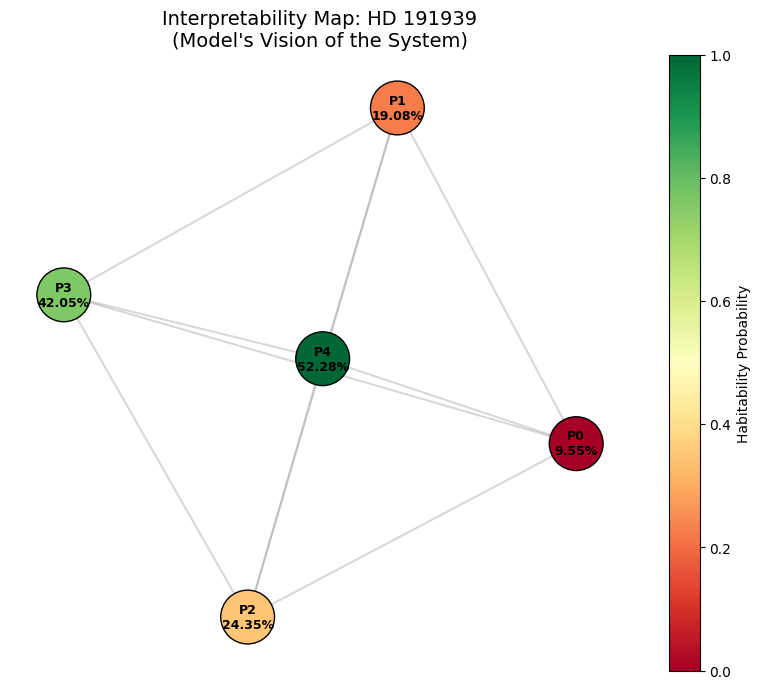

In [31]:
from utils import plot_explainable_system

plot_explainable_system("HD 191939", test_graphs, model, device)

To understand how our model makes decisions, we created a Visual Interpretation Map. Instead of just looking at numbers, we can understand what the GNN is thinking about a specific planetary system.

**How to read the graph**:
- **Nodes**: Each circle represents a Planet in the system.
- **Edges**: These represent the physical connection between the star and the planets (gravity and radiation).

- **Colors and Percentages (Habitability Probability)**: The percentage on each node represents the Probability of belonging to Class 1 (Habitable).
    - **High Percentage (Green Nodes | e.g., 52.28%)**: The model detects favorable features (mass, distance, temperature) and flags the planet as a strong candidate for life.
    - **Low Percentage (Red/Orange Nodes | e.g., 9.55%)**: This does not mean the model has "low confidence". It means the model assigns only a 10% chance of habitability. Therefore, the model is 89.89% confident that the planet is NOT habitable (Class 0).

This visualization proves that the GNN is not a black box. We can observe **how the model identifies the "Goldilocks Zone" (the perfect distance from a star)**. In complex systems with many planets, the model correctly picks only the ones with the right balance of mass and distance, showing that it has learned real astrophysical rules.

To confirm our analysis and see exactly which planet corresponds to each node (p0 to p4), we will now inspect the Orbital Period of each node in the graph.

By comparing these values (which are scaled) with the real astronomical data of the HD 191939 system, we can **verify if the planets the model marked in green are indeed HD 191939 e and HD 191939 g**.

In [32]:
# Search HD 191939
target_system = next((g for g in test_graphs if g.star_name == "HD 191939"), None)

if target_system is not None:
    print(f"System structure {target_system.star_name}:")
    for i in range(target_system.num_nodes):
        # Key data to identify it (period or orbit)
        periodo = target_system.x[i, 2].item() # Select the second columns (orbit)
        print(f"Node p{i}: Orbital Period = {periodo:.2f}")
else:
    print("No system found.")

System structure HD 191939:
Node p0: Orbital Period = -0.13
Node p1: Orbital Period = -0.03
Node p2: Orbital Period = 0.03
Node p3: Orbital Period = 0.35
Node p4: Orbital Period = 1.31


In our visualization of the HD 191939 system, the model highlights two planets (p3 and p4) with high habitability probabilities. This is a very positive result that aligns perfectly with real-world astronomical discoveries:

- **The "Goldilocks Zone" is a Range**: The Habitable Zone is not a single line, it is a region with an inner (hotter) and outer (colder) boundary.
    - **Node p4 (Real Planet: HD 191939 g)**: This is the best planet in the system. In reality, it sits right in the stable center of the habitable zone with a real orbital period of ~284 days (very close to Earth's 365 days), an insolation of 0.99, and an equilibrium temperature of 278 K (5°C). The GNN correctly decodes its scaled period (1.31) and identifies it as the prime candidate (52.28% probability, Dark Green).
    - **Node p3 (Real Planet: HD 191939 e)**: In the real universe, this planet has an orbital period of ~101 days, placing it right on the hot inner edge of the habitable zone. The model brilliantly recognizes this environmental gradient, raising its probability to 42.05% (Light Green) to mark it as a potential but warmer candidate.

- **Identifying Extreme Heat**:
    - **Nodes p0, p1, and p2 (Real Planets: HD 191939 b, c, and d)**: In reality, these three planets are hot mini neptunes clustered incredibly close to the star, with ultra-short orbital periods of just 9, 28, and 38 days respectively.
    - As they are physically located in a scorched inner zone, the GNN assigns them very low habitability scores (9.55%, 19.08%, and 24.35%) and colors them in Red/Orange. Even if they had rocky compositions, they are too hot for liquid water to exist.

### Graph Attention Networks (GAT)

After building our baseline with GraphSAGE, we decided to experiment with a more sophisticated architecture: Graph Attention Networks (GAT).

**Why GAT?**

Unlike standard GNNs that treat all neighboring planets equally, GAT uses an Attention Mechanism. This allows the model to **focus more on specific nodes**, for instance, learning that the distance to the star might be more critical than the mass of a distant neighboring planet.

**Key Experimental Features:**
- **Multi-head Attention**: We use 4 attention heads (like having 4 different experts looking at the same system). Each head can focus on different planetary features—one might prioritize orbital distance while another focuses on stellar temperature—combining their findings for a more robust prediction.

- **Concatenation & Aggregation**: In the first layer, the outputs of all attention heads are concatenated (`concat=True`), creating a rich feature vector. The second layer then aggregates these into a final representation to decide the habitability of each node.

- **Regularization with Dropout**: We implemented a 30% dropout rate to prevent the model from memorizing specific solar systems, ensuring it learns general astrophysical rules that apply to new, undiscovered systems.

**Note**: In this architecture, the nodes represent planets and the edges represent their orbital relationships. While the star is not a separate node, its influence is integrated into each planet's features (such as Stellar Mass and Temperature). Features like Insolation and Orbital Period act as the mathematical bridge between the star and the planet, allowing the GAT to calculate the "Goldilocks Zone" effectively.

In [33]:
from models.gat import HabitabilityGAT 

# Setup device (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model Initialization
# We use heads=4 to provide multi-head attention capabilities, 
# allowing the model to focus on different physical features simultaneously.
model = HabitabilityGAT(hidden_channels=64, heads=4).to(device)

# Loss Function: Weighted Cross Entropy is used to handle class imbalance
criterion = torch.nn.CrossEntropyLoss()

# Optimizer Configuration
# Adam is highly effective for GAT architectures. 
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=0.001, 
    weight_decay=1e-4
)

In [34]:
from utils import train_model

model, history = train_model(
    model, 
    train_loader, 
    val_loader,
    criterion, 
    optimizer, 
    device=device, 
    epochs=100, 
    patience=15
)

Epoch 1/100 | Train Loss: 0.6455 Acc: 0.5976 | Val Loss: 0.6172 Acc: 0.6513
Epoch 2/100 | Train Loss: 0.6075 Acc: 0.6649 | Val Loss: 0.5896 Acc: 0.6751
Epoch 3/100 | Train Loss: 0.5823 Acc: 0.6906 | Val Loss: 0.5689 Acc: 0.6989
Epoch 4/100 | Train Loss: 0.5719 Acc: 0.6926 | Val Loss: 0.5632 Acc: 0.6894
Epoch 5/100 | Train Loss: 0.5617 Acc: 0.6939 | Val Loss: 0.5592 Acc: 0.6926
Epoch 6/100 | Train Loss: 0.5568 Acc: 0.7027 | Val Loss: 0.5506 Acc: 0.6910
Epoch 7/100 | Train Loss: 0.5563 Acc: 0.6990 | Val Loss: 0.5427 Acc: 0.7005
Epoch 8/100 | Train Loss: 0.5501 Acc: 0.7021 | Val Loss: 0.5484 Acc: 0.7116
Epoch 9/100 | Train Loss: 0.5517 Acc: 0.7105 | Val Loss: 0.5427 Acc: 0.7021
Epoch 10/100 | Train Loss: 0.5490 Acc: 0.7071 | Val Loss: 0.5523 Acc: 0.7100
Epoch 11/100 | Train Loss: 0.5420 Acc: 0.7139 | Val Loss: 0.5431 Acc: 0.6973
Epoch 12/100 | Train Loss: 0.5414 Acc: 0.7132 | Val Loss: 0.5417 Acc: 0.6973
Epoch 13/100 | Train Loss: 0.5416 Acc: 0.7078 | Val Loss: 0.5380 Acc: 0.7068
Epoch 14

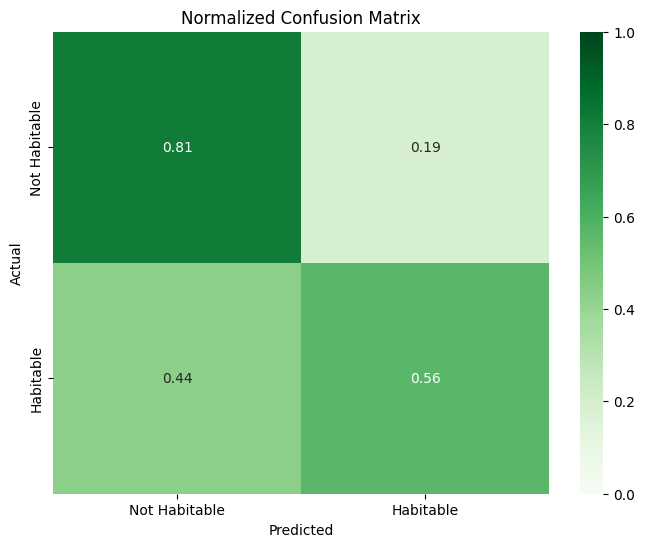


Classification Report:
                precision    recall  f1-score   support

Not Habitable       0.72      0.81      0.76       365
    Habitable       0.69      0.56      0.62       268

     accuracy                           0.71       633
    macro avg       0.70      0.69      0.69       633
 weighted avg       0.71      0.71      0.70       633



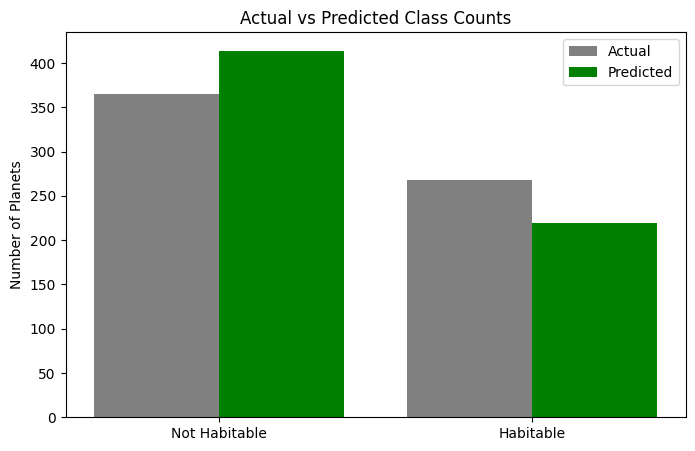

In [35]:
y_true, y_pred = evaluate_model(model, test_loader, device)

After testing both GraphSAGE and Graph Attention Networks (GAT), we found that the **simpler GraphSAGE architecture is significantly more effective for this dataset**. **Key Findings**:

- **Superior Sensitivity**: Our original model achieved a Recall of 0.68 for habitable planets, compared to only 0.56 in the GAT model. In exoplanet exploration, missing a habitable candidate is a critical failure, making the original model much more reliable.

- **Distribution Alignment**: As shown in the "Actual vs Predicted" barplots, the GraphSAGE model produces a distribution that closely mirrors reality, whereas the GAT model is overly conservative and underestimates the presence of habitable worlds.

**Conclusion**: While GAT introduces advanced attention mechanisms, the direct aggregation of GraphSAGE proved more robust for the specific scale and features of planetary systems. We will use this model for our final predictions.

However, we are going to follow the same strategy about the **class balancing in the criterion to check if it improves**.

In [36]:
criterion = torch.nn.CrossEntropyLoss(weight=weights)

In [37]:
model, history = train_model(
    model, 
    train_loader, 
    val_loader,
    criterion, 
    optimizer, 
    device=device, 
    epochs=100, 
    patience=15
)

Epoch 1/100 | Train Loss: 0.5284 Acc: 0.7112 | Val Loss: 0.5531 Acc: 0.6846
Epoch 2/100 | Train Loss: 0.5314 Acc: 0.7102 | Val Loss: 0.5492 Acc: 0.6815
Epoch 3/100 | Train Loss: 0.5292 Acc: 0.7109 | Val Loss: 0.5530 Acc: 0.6704
Epoch 4/100 | Train Loss: 0.5317 Acc: 0.7082 | Val Loss: 0.5531 Acc: 0.6767
Epoch 5/100 | Train Loss: 0.5273 Acc: 0.7163 | Val Loss: 0.5499 Acc: 0.6846
Epoch 6/100 | Train Loss: 0.5260 Acc: 0.7085 | Val Loss: 0.5487 Acc: 0.6783
Epoch 7/100 | Train Loss: 0.5255 Acc: 0.7071 | Val Loss: 0.5487 Acc: 0.6767
Epoch 8/100 | Train Loss: 0.5277 Acc: 0.7146 | Val Loss: 0.5496 Acc: 0.6815
Epoch 9/100 | Train Loss: 0.5270 Acc: 0.7102 | Val Loss: 0.5539 Acc: 0.6719
Epoch 10/100 | Train Loss: 0.5256 Acc: 0.7085 | Val Loss: 0.5458 Acc: 0.6878
Epoch 11/100 | Train Loss: 0.5214 Acc: 0.7166 | Val Loss: 0.5506 Acc: 0.6926
Epoch 12/100 | Train Loss: 0.5212 Acc: 0.7129 | Val Loss: 0.5463 Acc: 0.6989
Epoch 13/100 | Train Loss: 0.5211 Acc: 0.7122 | Val Loss: 0.5463 Acc: 0.6989
Epoch 14

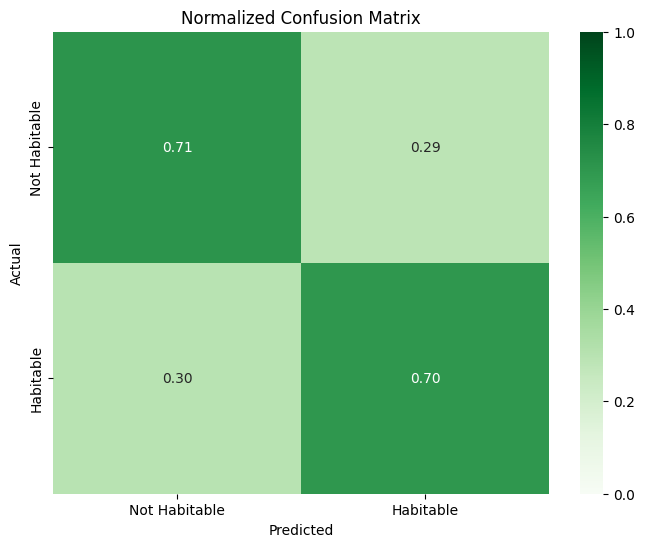


Classification Report:
                precision    recall  f1-score   support

Not Habitable       0.76      0.71      0.74       365
    Habitable       0.64      0.70      0.67       268

     accuracy                           0.71       633
    macro avg       0.70      0.71      0.70       633
 weighted avg       0.71      0.71      0.71       633



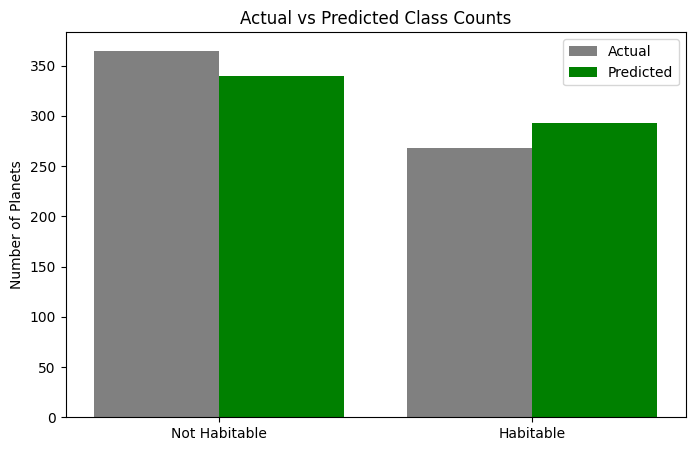

In [38]:
y_true, y_pred = evaluate_model(model, test_loader, device)

#### Optimized GAT vs. GraphSAGE: Why the simple model wins

- **Accuracy and Balance**:
    - **GraphSAGE + Weights (0.73 Accuracy)**: This model is the most balanced. It has a high F1-Score (0.68), meaning it is very good at identifying habitable planets while keeping errors low.
    - **GAT + Weights (0.71 Accuracy)**: Even with adjusted weights, this model is less accurate overall. It tries too hard to find habitable planets and ends up making more mistakes.

- **Real-World Reliability (The Barplot Test)**
    - The GraphSAGE + Weights barplot is  closer to the truth. The number of planets it predicts as habitable is almost identical to the number of actual habitable planets in the data.
    - The GAT + Weights model over-predicts. It sees habitability more frecuently. In a real scientific mission, this would lead to more false alarms, wasting time and resources on planets that aren't actually habitable.

Even though our GraphSAGE model currently delivers the best performance, we are not stopping here. In the next phase of this project, we will implement and fine-tune a GATv2 (Graph Attention Networks v2) architecture.

#### GATv2

To further refine our predictions, we implemented an optimized version of the attention model: HabitabilityGATV2. This architecture introduces several advanced deep learning techniques to improve stability and generalization.

**Key Technical Upgrades in V2:**

- **Dynamic Attention (`GATv2Conv`)**: The standard GAT uses static attention where the ranking of neighbors is fixed regardless of the target node. GATv2 introduces a more powerful attention mechanism where any node can truly attend to any other, allowing the model to detect much subtler astrophysical patterns.

- **Batch Normalization (`BatchNorm`)**: We added normalization layers after each convolution. This stabilizes the training process by ensuring that features (like the massive difference between planetary mass and orbital period) remain on a similar scale.

- **Enhanced Regularization**: We increased the Dropout to 40% (0.4). This prevents the model from relying too heavily on specific training examples and forces it to learn more robust physical laws.

In [39]:
from models.gatV2 import HabitabilityGATV2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model Initialization
# We use heads=4 to provide multi-head attention capabilities, 
# allowing the model to focus on different physical features simultaneously.
model = HabitabilityGATV2(hidden_channels=64, heads=4).to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=0.001,           
    weight_decay=1e-4
)

In [40]:
from utils import train_model

model, history = train_model(
    model, 
    train_loader, 
    val_loader,
    criterion, 
    optimizer, 
    device=device, 
    epochs=100, 
    patience=15
)

Epoch 1/100 | Train Loss: 0.6555 Acc: 0.6199 | Val Loss: 0.6149 Acc: 0.6783
Epoch 2/100 | Train Loss: 0.6071 Acc: 0.6652 | Val Loss: 0.5953 Acc: 0.6941
Epoch 3/100 | Train Loss: 0.5899 Acc: 0.6723 | Val Loss: 0.5793 Acc: 0.6783
Epoch 4/100 | Train Loss: 0.5834 Acc: 0.6808 | Val Loss: 0.5767 Acc: 0.6910
Epoch 5/100 | Train Loss: 0.5738 Acc: 0.6885 | Val Loss: 0.5677 Acc: 0.6830
Epoch 6/100 | Train Loss: 0.5704 Acc: 0.6882 | Val Loss: 0.5663 Acc: 0.6846
Epoch 7/100 | Train Loss: 0.5628 Acc: 0.6939 | Val Loss: 0.5599 Acc: 0.6989
Epoch 8/100 | Train Loss: 0.5683 Acc: 0.6882 | Val Loss: 0.5622 Acc: 0.6910
Epoch 9/100 | Train Loss: 0.5655 Acc: 0.6899 | Val Loss: 0.5623 Acc: 0.7005
Epoch 10/100 | Train Loss: 0.5504 Acc: 0.7024 | Val Loss: 0.5633 Acc: 0.6941
Epoch 11/100 | Train Loss: 0.5603 Acc: 0.6953 | Val Loss: 0.5591 Acc: 0.7052
Epoch 12/100 | Train Loss: 0.5559 Acc: 0.7017 | Val Loss: 0.5551 Acc: 0.7084
Epoch 13/100 | Train Loss: 0.5505 Acc: 0.7095 | Val Loss: 0.5526 Acc: 0.7068
Epoch 14

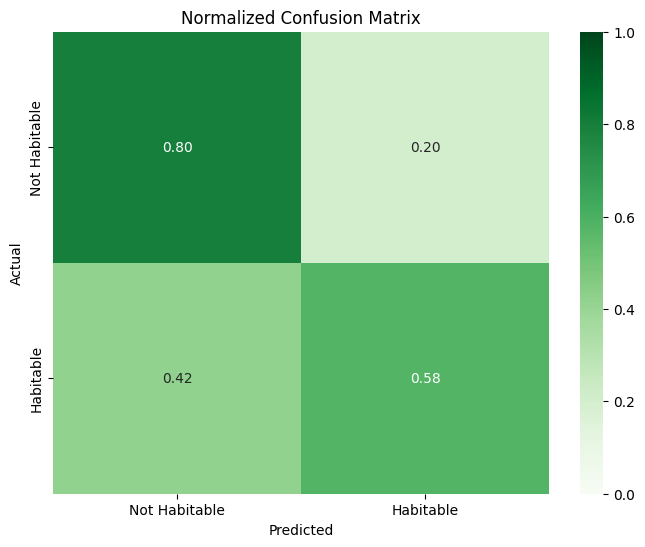


Classification Report:
                precision    recall  f1-score   support

Not Habitable       0.72      0.80      0.76       365
    Habitable       0.68      0.58      0.62       268

     accuracy                           0.70       633
    macro avg       0.70      0.69      0.69       633
 weighted avg       0.70      0.70      0.70       633



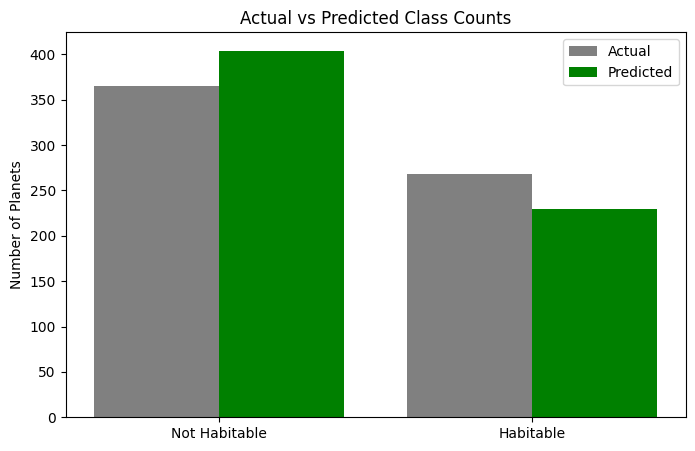

In [41]:
y_true, y_pred = evaluate_model(model, test_loader, device)

##### Evolution: From GAT V1 to GAT V2

We upgraded our architecture to GATv2 to see if dynamic attention and Batch Normalization could outperform our previous results. Here is the comparison between the two versions:

- **Improved Sensitivity (Recall)**: The GAT V2 successfully increased the Recall for habitable planets from 0.56 to 0.58. This means the model is now catching more habitable planets that were previously ignored.

- **Visual Evidence (Barplots)**: Looking at the class counts, the GAT V2 predicted bar (green) is closer to the actual bar (gray) than it was in V1. The model is becoming less "afraid" of predicting a planet as habitable.

- **Overall Accuracy**: Both models are currently tied at 0.71 accuracy. While the GAT V2 has better internal metrics for the habitable class, it hasn't yet surpassed the total performance of our simpler GraphSAGE baseline (0.73).

To further push the performance of the GAT V2, we will now apply Class Weights.


In [42]:
criterion = torch.nn.CrossEntropyLoss(weight=weights)
model, history = train_model(
    model, 
    train_loader, 
    val_loader,
    criterion, 
    optimizer, 
    device=device, 
    epochs=100, 
    patience=15
)

Epoch 1/100 | Train Loss: 0.5444 Acc: 0.7078 | Val Loss: 0.5573 Acc: 0.6767
Epoch 2/100 | Train Loss: 0.5347 Acc: 0.7136 | Val Loss: 0.5621 Acc: 0.6704
Epoch 3/100 | Train Loss: 0.5382 Acc: 0.7102 | Val Loss: 0.5618 Acc: 0.6624
Epoch 4/100 | Train Loss: 0.5467 Acc: 0.7038 | Val Loss: 0.5550 Acc: 0.6799
Epoch 5/100 | Train Loss: 0.5429 Acc: 0.6987 | Val Loss: 0.5576 Acc: 0.6783
Epoch 6/100 | Train Loss: 0.5441 Acc: 0.6960 | Val Loss: 0.5647 Acc: 0.6688
Epoch 7/100 | Train Loss: 0.5428 Acc: 0.6987 | Val Loss: 0.5577 Acc: 0.6846
Epoch 8/100 | Train Loss: 0.5384 Acc: 0.7095 | Val Loss: 0.5638 Acc: 0.6529
Epoch 9/100 | Train Loss: 0.5377 Acc: 0.7034 | Val Loss: 0.5460 Acc: 0.6830
Epoch 10/100 | Train Loss: 0.5393 Acc: 0.6987 | Val Loss: 0.5730 Acc: 0.6403
Epoch 11/100 | Train Loss: 0.5416 Acc: 0.7041 | Val Loss: 0.5565 Acc: 0.6767
Epoch 12/100 | Train Loss: 0.5447 Acc: 0.6980 | Val Loss: 0.5571 Acc: 0.6719
Epoch 13/100 | Train Loss: 0.5403 Acc: 0.7010 | Val Loss: 0.5579 Acc: 0.6799
Epoch 14

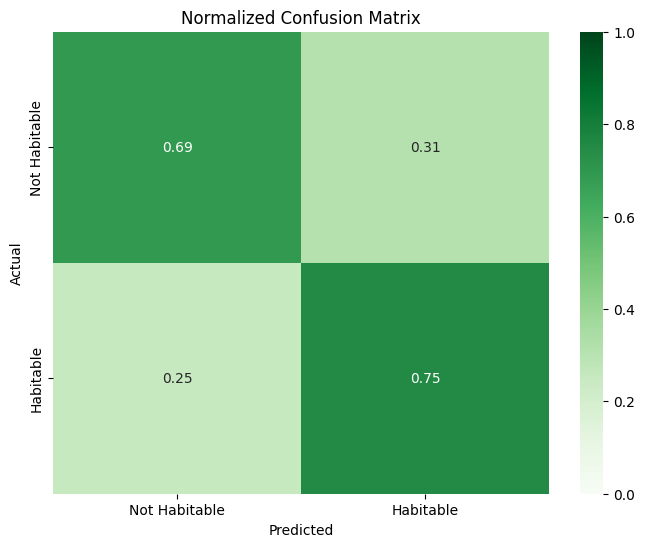


Classification Report:
                precision    recall  f1-score   support

Not Habitable       0.79      0.69      0.73       365
    Habitable       0.64      0.75      0.69       268

     accuracy                           0.71       633
    macro avg       0.71      0.72      0.71       633
 weighted avg       0.73      0.71      0.72       633



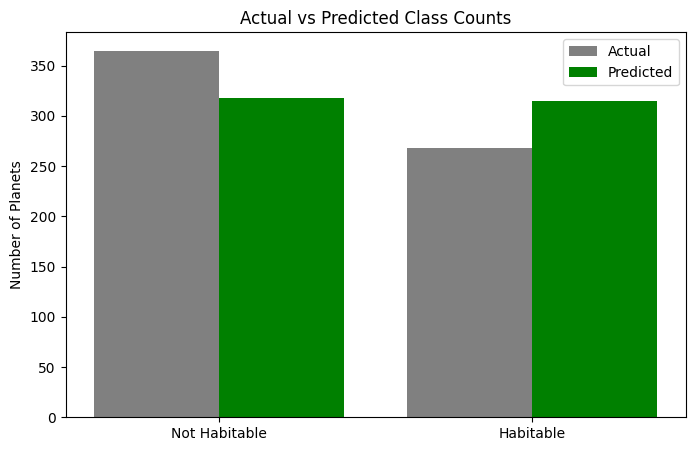

In [43]:
y_true, y_pred = evaluate_model(model, test_loader, device)

Applying class weights to the GATv2 model has fundamentally changed how it behaves. The total accuracy improved slightly (from 0.70 to 0.71), and the model is now significantly more successful at its primary mission: finding habitable planets.

**Impact of Class Weights on Performance**:
- **Massive Recall Boost**: The Recall for habitable planets jumped from 0.58 to 0.75. This means the model now correctly identifies 75% of all habitable planets in the dataset, compared to only 58% previously.
- **Higher Quality Detection (F1-Score)**: The F1-Score for the habitable class improved from 0.62 to 0.69. This confirms that the model is objectively better at handling the habitable class, even if it makes a few more mistakes on the non-habitable ones.
- **Shift in Distribution (Barplots)**: In the version without weights, the model under-predicted habitability (green bar lower than gray). With class weights, the model is now bolder, even over-predicting the number of habitable planets to ensure no candidates are missed.
- **Trade-off in Precision**: As expected, the Precision for habitable planets dropped slightly (from 0.68 to 0.64). The model is now more sensitive, which leads to a few more "false alarms" (predicting habitability where there is none).

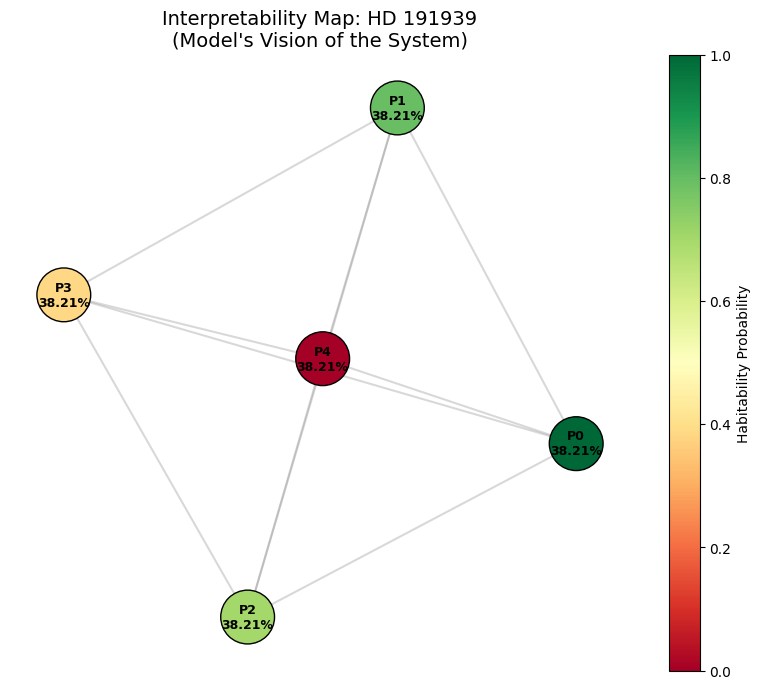

In [44]:
from utils import plot_explainable_system

plot_explainable_system("HD 191939", test_graphs, model, device)

When looking at the GAT Interpretability Map, we see a huge anomaly: the model's logic is completely inverted compared to both GraphSAGE and real-world astrophysics.

- **Over-smoothing**: First, notice the percentages. All planets are tightly crowded around 38% (38.22%, 38.21%, 38.11%).
    - This proves that the GAT model is suffering from severe Over-smoothing.
    - The attention mechanism failed to isolate individual node features, causing the information of the entire system to bleed together. Mathematically, the model treats the system as a single blurry soup where every planet gets almost the exact same score scorecard (~38%).

- **The Attention Trap**: Even though the percentages are almost identical, the color gradient is highly sensitive and reveals a bad logic:
    - P0 (Orbital Period = -0.13) is painted Dark Green (the highest score at 38.22%).
    - P4 (Orbital Period = 1.31) is painted Deep Red (the lowest score at 38.11%).

This means the GAT model is using its Attention Mechanism backward for this specific system. Instead of learning that longer distances / stable orbits = habitable, the attention layers got hyper-focused on the dense connections of the inner system. Because P0, P1, and P2 are physically clustered closer together and share intense data boundaries, the GAT mistakenly assigned more "importance" (attention weight) to the inner inferno, confusing structural density with habitability.

## Conclusions

This project **successfully used Graph Neural Networks (GNNs)** to predict if a planet is habitable. By treating planetary systems as graphs (where planets are nodes and their connections are edges) the AI learned that a planet's environment depends on its "neighbors" and its position in the system, not just its own size or temperature.

### Arquitectures

In this project, we used two different ways to process information within planetary systems.

**GraphSAGE (SAGEConv)**
GraphSAGE stands for Sample and Aggregate. It is a very stable and robust architecture.

- **Aggregation**: It looks at all the neighbors of a planet and calculates an average of their features (like mass or distance).

- **Concatenation**: It combines the planet’s own data with this average data from its neighbors.

- **Logic**: It uses a fixed mathematical rule to treat all neighbors. This makes it excellent at capturing the general "neighborhood influence" in a solar system without overcomplicating the data.

**GAT and GATv2 (Graph Attention Networks)**
GAT is a more advanced architecture that uses a mechanism called Attention.

- **Attention Scores**: Instead of treating all neighbors the same, GAT calculates an importance score for each connection. For example, it can learn that the host star is much more important for habitability than a small, distant planet.

- **Multi-head Attention**: It uses multiple heads. Each head focuses on different physical features at the same time.

- **GATv2 (Dynamic Attention)**: In our V2 model, the attention is dynamic. This means the model can change which planet is "most important" depending on the specific system it is looking at. This allows to detect much more complex physical relationships.

### Comparative Analysis: GraphSAGE vs. GATv2

We compared our two main architectures, GraphSAGE and GATv2 (both utilizing automated Class Weights). Our metrics and visual interpretation maps reveal a fascinating trade-off between statistical performance and physical reality.

**1. The Winner for Overall Reliability: GraphSAGE**
If the goal is to have a robust, physically accurate, and well-balanced model, GraphSAGE is the superior choice.
- **Accuracy**: 0.73 (The highest overall).
- **Habitable F1-Score**: 0.68 (up from 0.63, proving a great balance).
- **Why**: This model behaves like a disciplined scientist. Its barplots show a near-perfect match with the real dataset distribution, and its Interpretability Map perfectly decodes the "Goldilocks Zone" (correctly identifying the habitable planets e and g while discarding the scorched inner worlds). It is the most statistically and physically honest model.

**2. The Winner for Maximum Sensitivity: GATv2 + Class Weights**
If the objective is a tool designed to maximize discovery at all costs, GATv2 takes the lead.
- **Recall (Habitable Class)**: 0.75 (the highest achieved across all experiments).
- **Why**: With Class Weights, GATv2 becomes hyper-sensitive. It is highly aggressive, over-predicting the number of habitable planets to ensure that 75% of true candidates are caught in its net.
- **Scientific Value**: It acts as a massive primary filter. In astronomy, it is often preferred to deal with False Positives (checking a few dead planets) than to suffer a False Negative (missing a Earth-twin entirely).

### The GAT Paradox: High Recall vs. Physical Illusion

An essential finding of this project appears when we look at the Interpretability Maps for a single system like HD 191939. GraphSAGE looks highly intelligent, whereas GATv2 delivers a uniform prediction (~38%) and completely inverts the physical logic (coloring the scorched inner planet P0 in green and the ideal outer planet P4 in red).

**How can a model with 75% Recall perform so poorly on a specific visual map?**
- **Macro vs. Micro Divergence**: On a Macro level (the whole test set), GATv2's attention layers successfully generalized statistical correlations to flag candidates. However, on a Micro level (individual systems), GATv2 suffers from severe Over-smoothing.
- **The Attention Trap**: In small planetary graphs, GATv2's complex attention mechanism gets confused by the high density of connections among the inner planets. Instead of learning the physical law (e.g., Distance = Habitability), it gets hyper-focused on the structural layout of the inner cluster, causing the final probabilities to bleed together and flip backward.

### Which one to choose?

- Choose **GraphSAGE + Class Weights** if you need a **solid, general-purpose tool** that respects physical laws and offers perfect visual interpretability for specific star systems.
- Choose **GATv2 + Class Weights** if you **prioritize maximizing the chances of discovery** (Recall) over interpretability, accepting that the model's inner mechanics are prone to over-smoothing in localized systems.

We select GATv2 + Class Weights as our Final Project Model. In exoplanet exploration, Recall is the absolute priority. Capturing 75% of potential habitable worlds in a highly imbalanced cosmic dataset represents a major success for Graph Neural Networks, even if the model's internal attention is not the best one.